# 📈 Cryptocurrency Market — Exploratory Data Analysis
**Goal:** Analyze price behavior, risk, returns, and correlations across 11 major cryptocurrencies over 5 years.

**Coins:** BTC, ETH, BNB, SOL, XRP, ADA, LTC, DOGE, AVAX, MATIC, LINK

**Categories:** Large Cap | Mid Cap | Meme | DeFi / Layer-1

**Skills demonstrated:** Time-series analysis, volatility modeling, risk-adjusted returns (Sharpe Ratio), technical indicators (RSI, Bollinger Bands), drawdown analysis, portfolio simulation, correlation analysis.

## 0. Setup

In [1]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Fetch Data — 5 Years

In [2]:
COINS = {
    'BTC':  'BTC-USD',
    'ETH':  'ETH-USD',
    'BNB':  'BNB-USD',
    'SOL':  'SOL-USD',
    'XRP':  'XRP-USD',
    'ADA':  'ADA-USD',
    'LTC':  'LTC-USD',
    'DOGE': 'DOGE-USD',
    'AVAX': 'AVAX-USD',
    'MATIC':'MATIC-USD',
    'LINK': 'LINK-USD'
}

START_DATE = '2021-04-10'
END_DATE   = '2026-04-10'

print(f'Fetching data from {START_DATE} to {END_DATE}...')

price_data = {}
for name, ticker in COINS.items():
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
        if not df.empty:
            close = df['Close']
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
            price_data[name] = close.squeeze()
            print(f'  ✅ {name} — {len(df)} rows')
        else:
            print(f'  ⚠️  {name} — no data')
    except Exception as e:
        print(f'  ❌ {name} — {e}')

prices = pd.DataFrame(price_data).ffill()
print(f'\nFinal shape: {prices.shape}')
prices.head()

Fetching data from 2021-04-10 to 2026-04-10...
  ✅ BTC — 1826 rows
  ✅ ETH — 1826 rows
  ✅ BNB — 1826 rows
  ✅ SOL — 1826 rows
  ✅ XRP — 1826 rows
  ✅ ADA — 1826 rows
  ✅ LTC — 1826 rows
  ✅ DOGE — 1826 rows
  ✅ AVAX — 1826 rows
  ✅ MATIC — 1445 rows
  ✅ LINK — 1826 rows

Final shape: (1826, 11)


,BTC,ETH,BNB,SOL,XRP,ADA,LTC,DOGE,AVAX,MATIC,LINK
Date,,,,,,,,,,,
2021-04-10,59793.234375,2135.942139,472.560333,26.841404,1.374416,1.218758,255.620193,0.063845,31.803802,0.358471,31.899261
2021-04-11,60204.964844,2157.656982,525.385559,27.931890,1.360530,1.266735,253.634460,0.074649,31.602322,0.370532,33.919182
2021-04-12,59893.453125,2139.353271,598.722656,28.512123,1.467735,1.316127,244.494370,0.070767,33.883968,0.358044,33.105427
2021-04-13,63503.457031,2299.187744,549.586548,27.435553,1.794001,1.411786,266.981476,0.093445,33.673531,0.422074,35.456635
2021-04-14,63109.695312,2435.104980,549.591858,26.475111,1.839236,1.455420,279.748413,0.121517,38.462868,0.414680,41.423710


## 2. Data Quality Check

In [3]:
print('Date range:', prices.index.min(), 'to', prices.index.max())
print('\nRows per coin:')
print(prices.count().sort_values())
print('\nMissing values:')
print(prices.isnull().sum())

Date range: 2021-04-10 00:00:00 to 2026-04-09 00:00:00

Rows per coin:
BTC      1826
ETH      1826
BNB      1826
SOL      1826
XRP      1826
ADA      1826
LTC      1826
DOGE     1826
AVAX     1826
MATIC    1826
LINK     1826
dtype: int64

Missing values:
BTC      0
ETH      0
BNB      0
SOL      0
XRP      0
ADA      0
LTC      0
DOGE     0
AVAX     0
MATIC    0
LINK     0
dtype: int64


## 3. Price History — All Coins

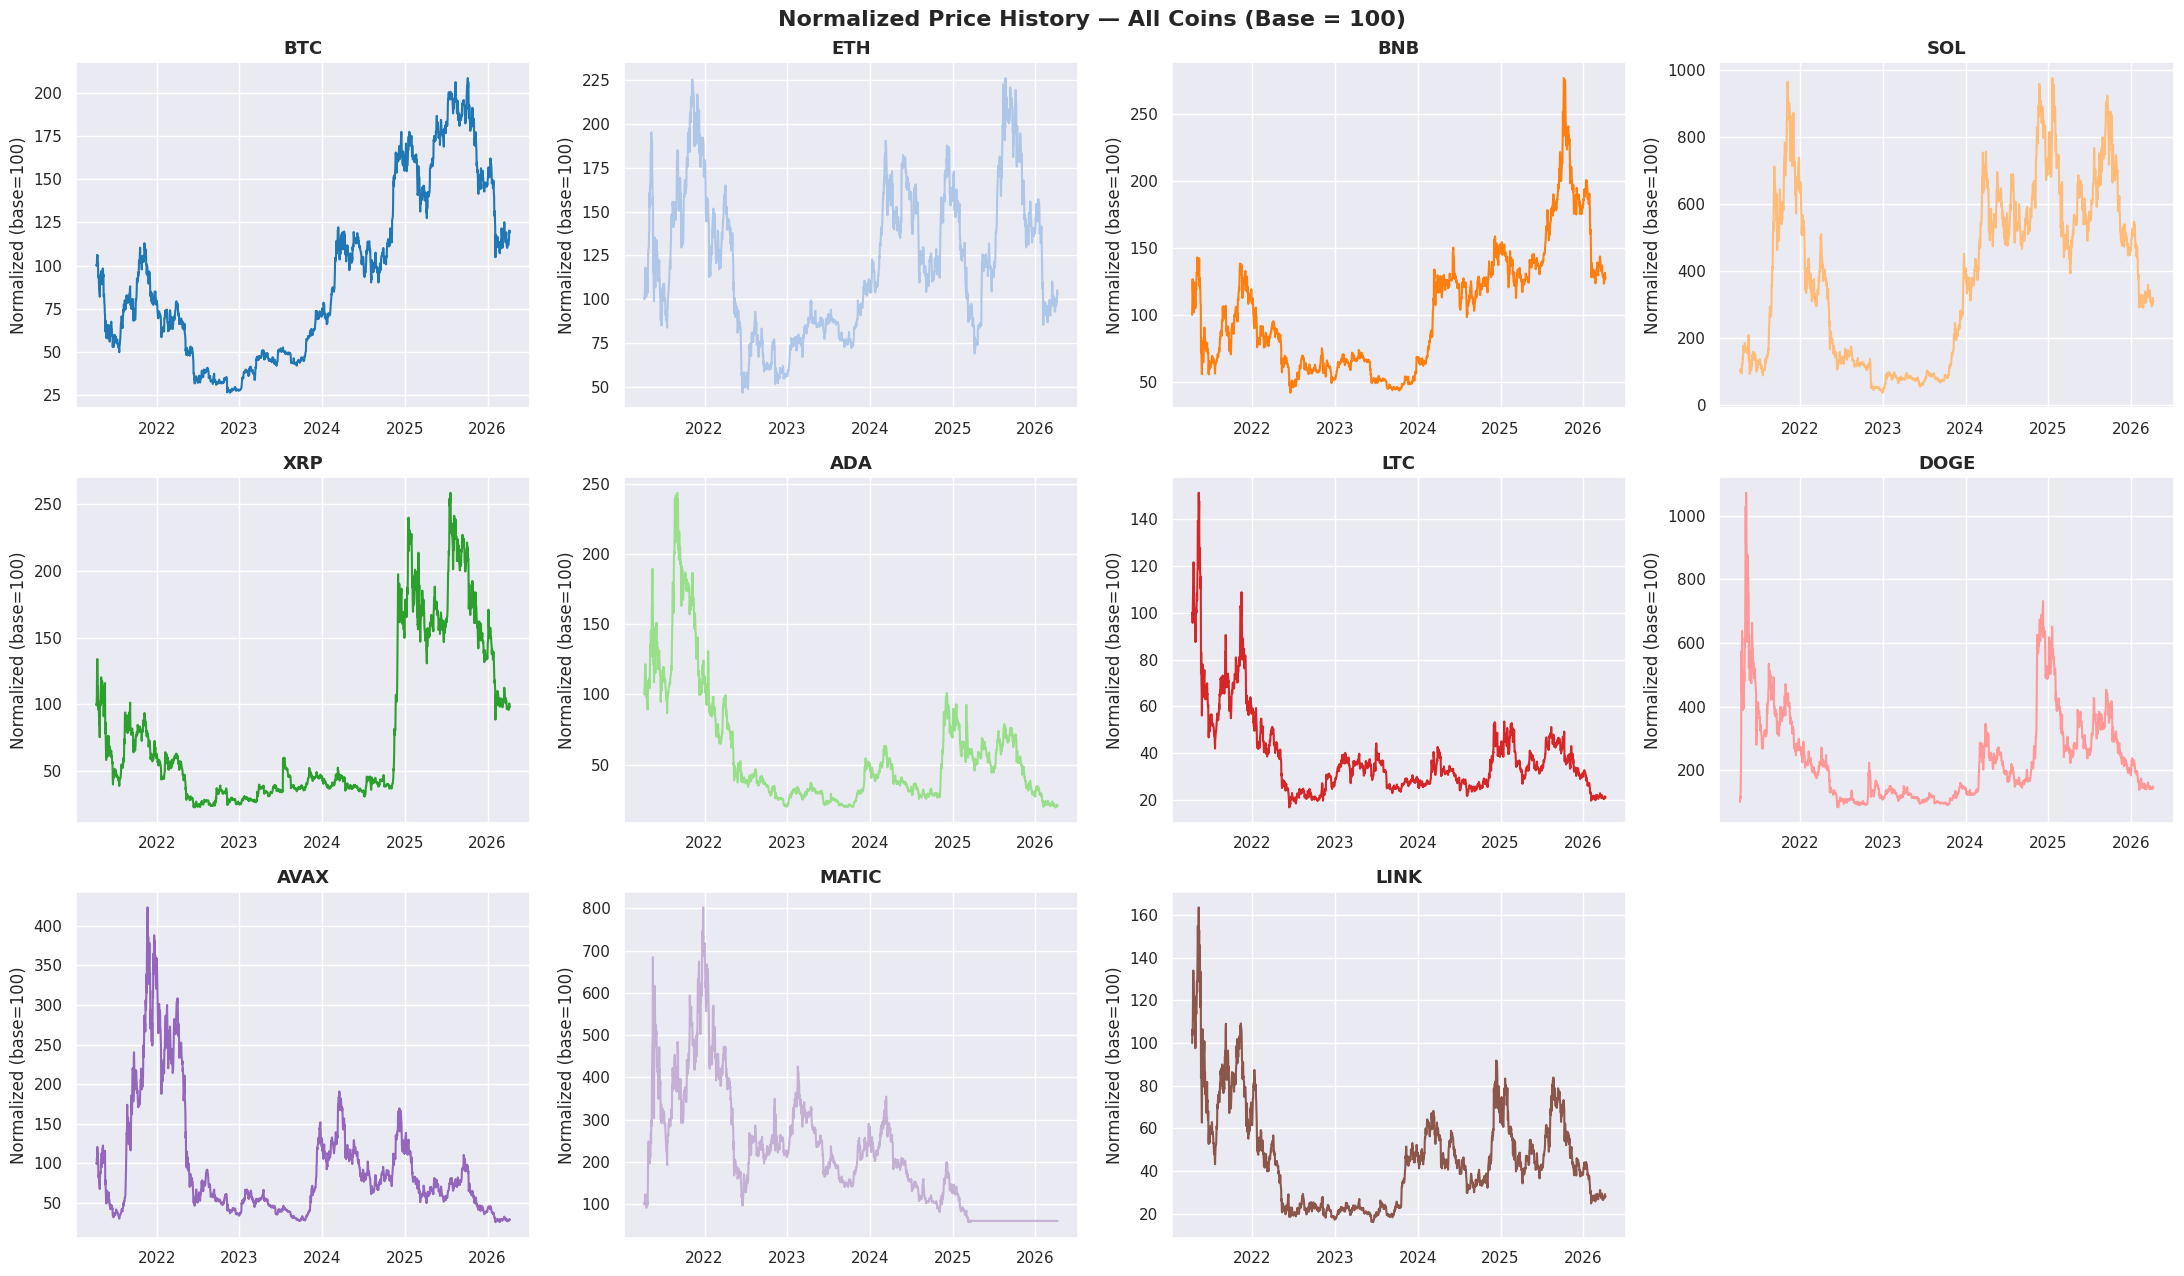

In [4]:
first_valid = {c: prices[c].dropna().iloc[0] for c in prices.columns if len(prices[c].dropna()) > 0}
normalized  = prices.copy()
for c in prices.columns:
    if c in first_valid:
        normalized[c] = prices[c] / first_valid[c] * 100

colors = plt.cm.tab20.colors
fig, axes = plt.subplots(3, 4, figsize=(22, 13))
axes = axes.flatten()

for i, coin in enumerate(prices.columns):
    col = normalized[coin].dropna()
    axes[i].plot(col.index, col.values, color=colors[i % 20], linewidth=1.5)
    axes[i].set_title(coin, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Normalized (base=100)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for j in range(len(prices.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Normalized Price History — All Coins (Base = 100)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

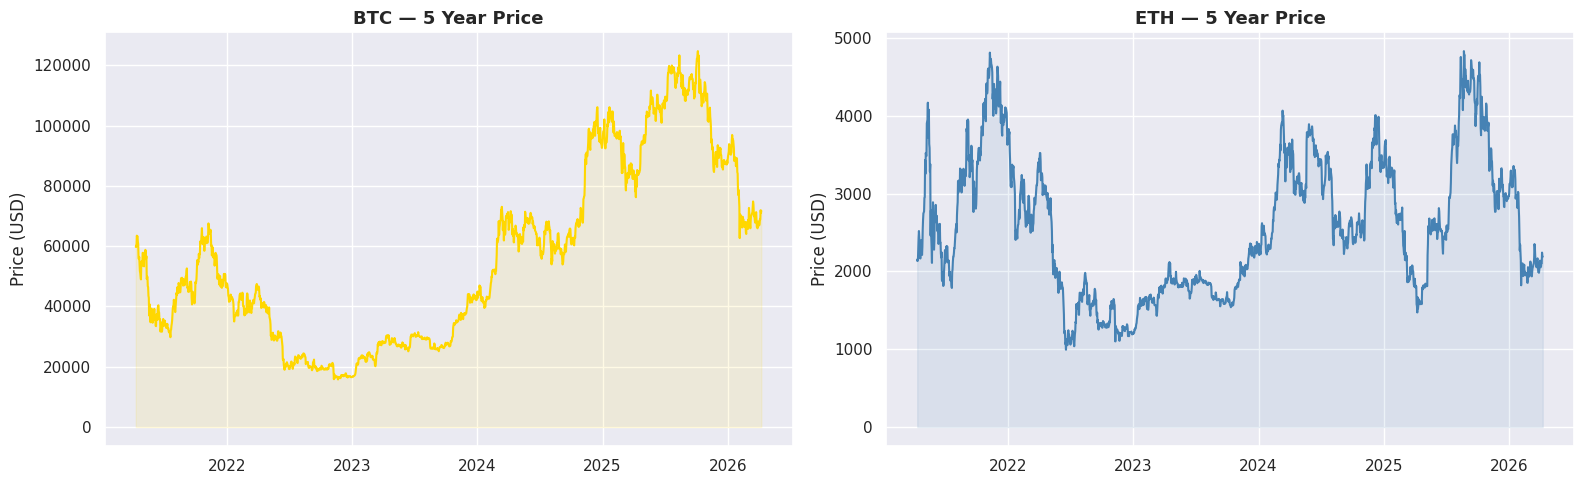

In [5]:
# BTC and ETH close-up
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, coin, color in zip(axes, ['BTC', 'ETH'], ['gold', 'steelblue']):
    if coin in prices.columns:
        col = prices[coin].dropna()
        ax.plot(col.index, col.values, color=color, linewidth=1.5)
        ax.fill_between(col.index, col.values, alpha=0.1, color=color)
        ax.set_title(f'{coin} — 5 Year Price', fontsize=13, fontweight='bold')
        ax.set_ylabel('Price (USD)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 4. Daily Returns

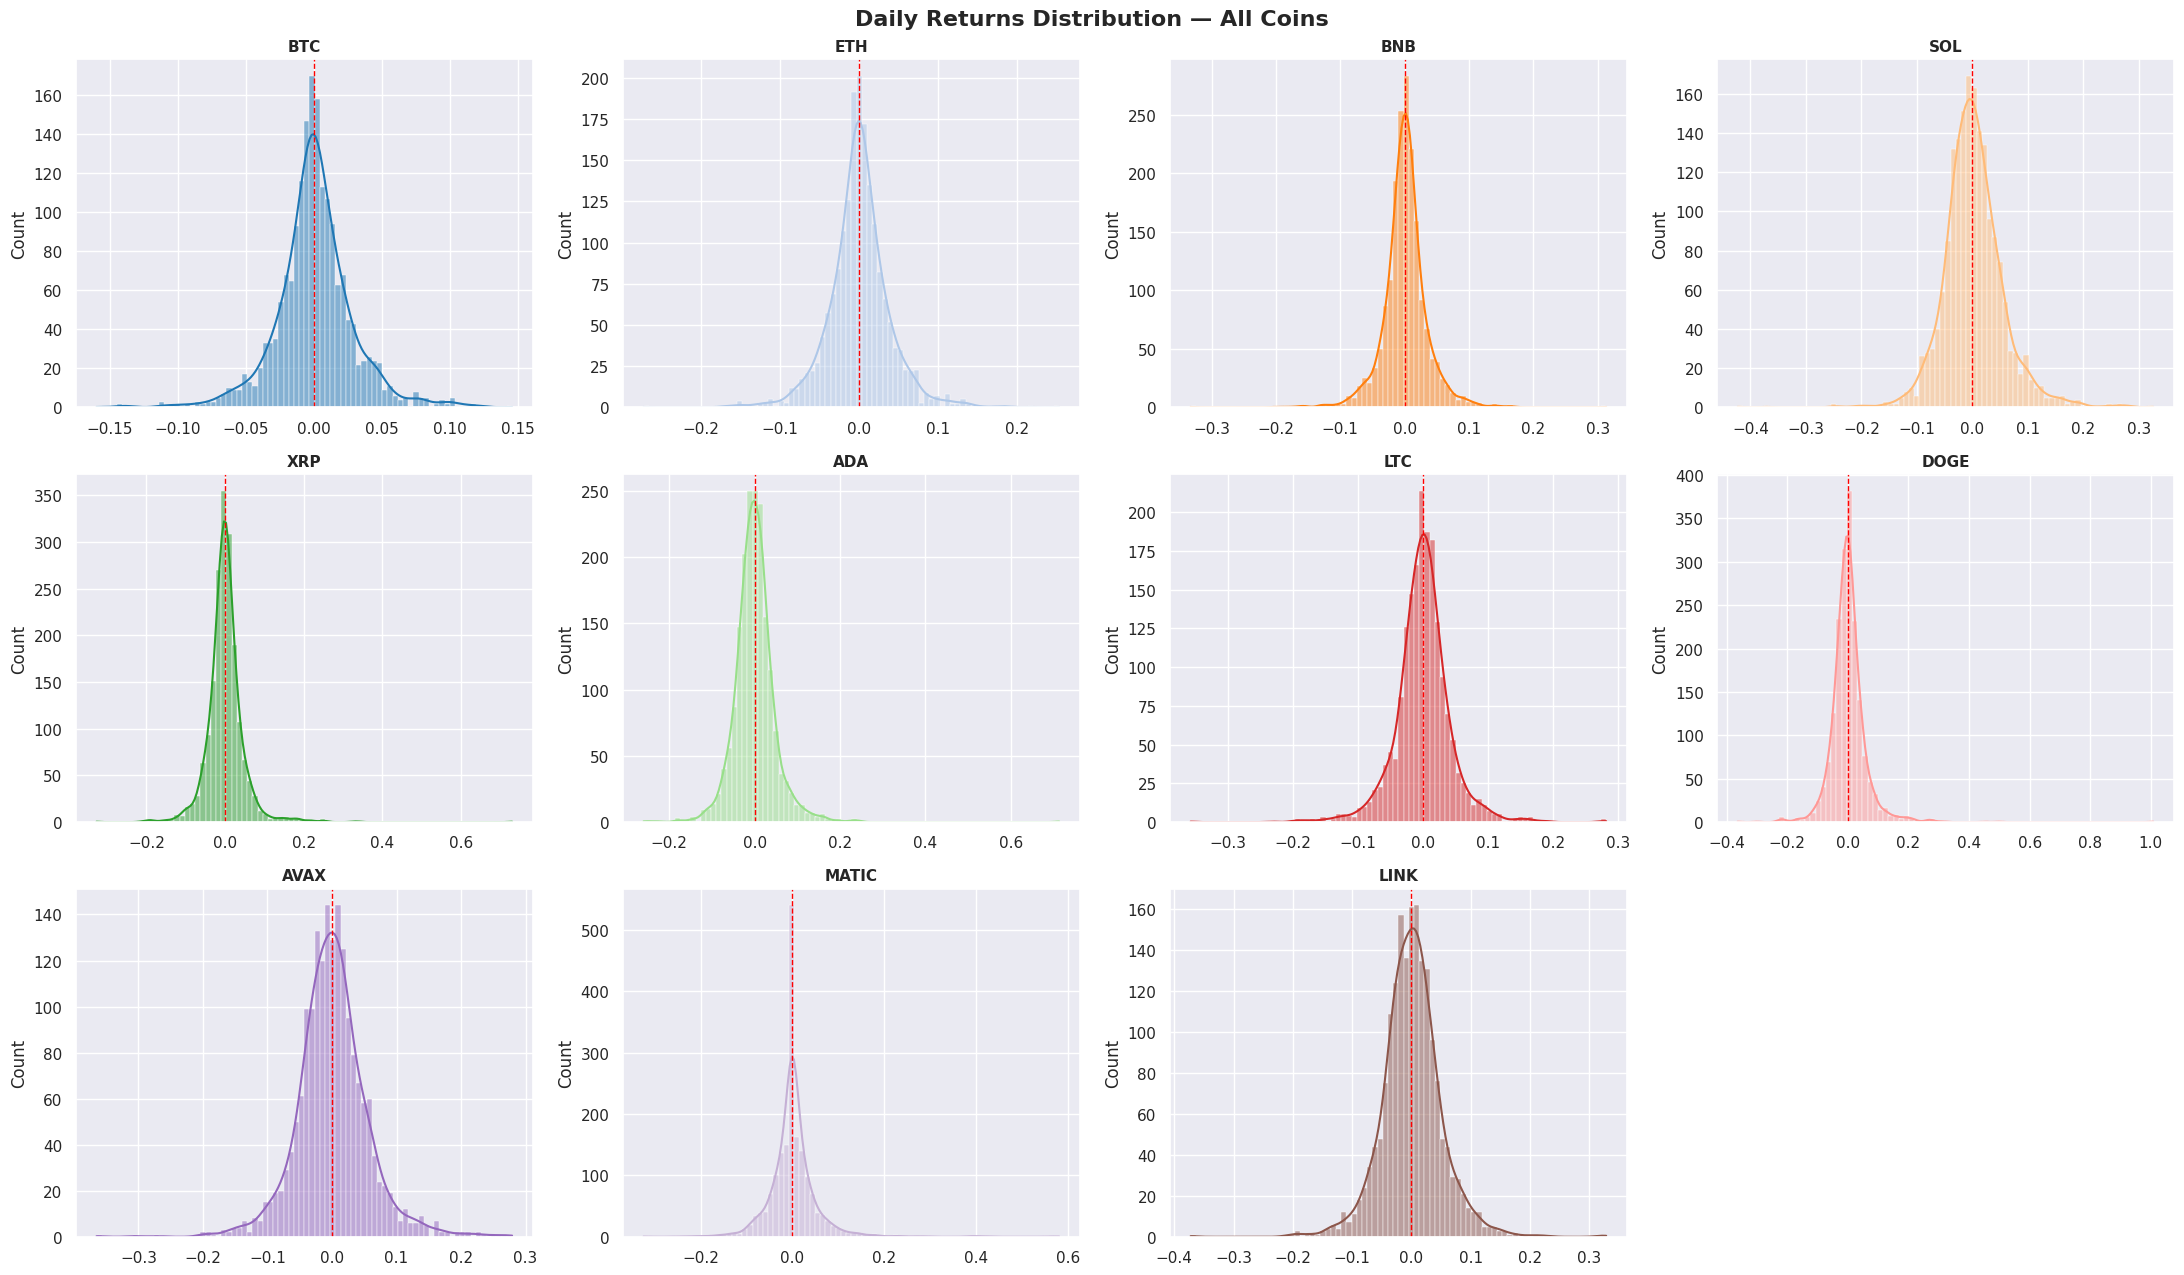

In [6]:
returns = prices.pct_change().dropna(how='all')

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
axes = axes.flatten()

for i, coin in enumerate(returns.columns):
    col = returns[coin].dropna()
    sns.histplot(col.values, kde=True, ax=axes[i], color=colors[i % 20], bins=80)
    axes[i].set_title(f'{coin}', fontsize=11, fontweight='bold')
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)

for j in range(len(returns.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Daily Returns Distribution — All Coins', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
stats = returns.describe().T
stats['skew']     = returns.skew()
stats['kurtosis'] = returns.kurtosis()
stats[['mean','std','min','max','skew','kurtosis']].round(4)

,mean,std,min,max,skew,kurtosis
BTC,0.0005,0.0294,-0.1597,0.1454,0.0001,3.6698
ETH,0.0008,0.0398,-0.2720,0.2531,0.1543,4.7907
BNB,0.0008,0.0358,-0.3327,0.3132,-0.1931,10.4872
SOL,0.0022,0.0557,-0.4228,0.3259,0.2017,5.9573
XRP,0.0011,0.0490,-0.3272,0.7308,2.4251,33.0726
ADA,0.0003,0.0492,-0.2601,0.7133,1.9323,26.7369
LTC,0.0001,0.0434,-0.3567,0.2820,-0.1786,6.9182
DOGE,0.0019,0.0614,-0.3639,1.0080,3.2594,46.3801
AVAX,0.0009,0.0559,-0.3650,0.2791,0.1556,3.9356
MATIC,0.0012,0.0550,-0.3239,0.5805,2.1708,20.7865


## 5. Volatility Analysis

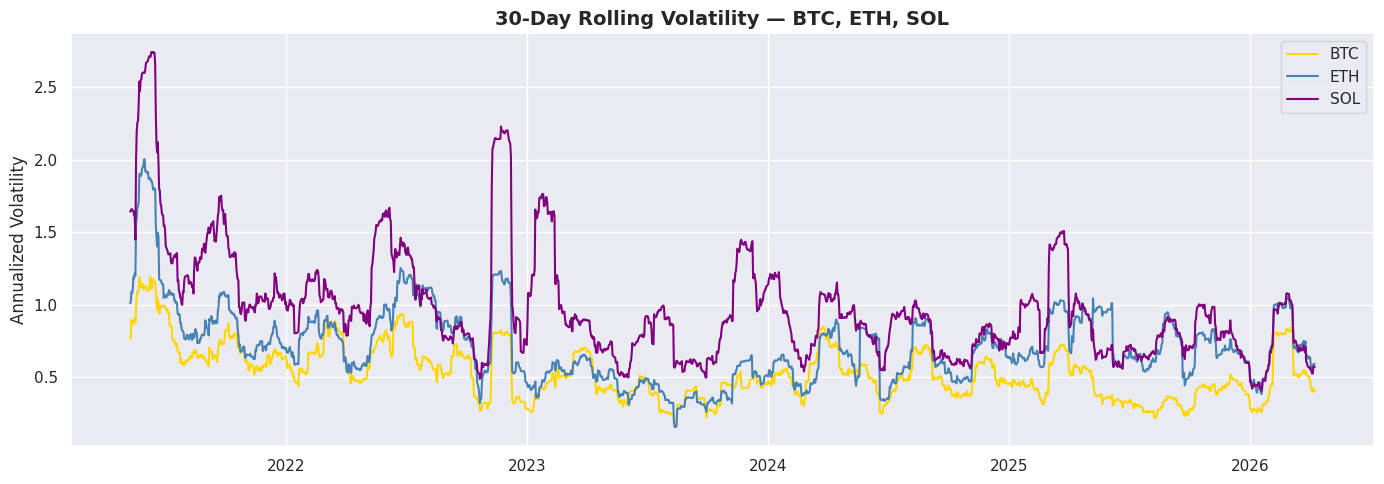

In [8]:
vol30 = returns.rolling(30).std() * np.sqrt(365)

plt.figure(figsize=(14, 5))
for coin, color in zip(['BTC','ETH','SOL'], ['gold','steelblue','purple']):
    if coin in vol30.columns:
        col = vol30[coin].dropna()
        plt.plot(col.index, col.values, label=coin, color=color, linewidth=1.5)
plt.title('30-Day Rolling Volatility — BTC, ETH, SOL', fontsize=14, fontweight='bold')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.tight_layout()
plt.show()

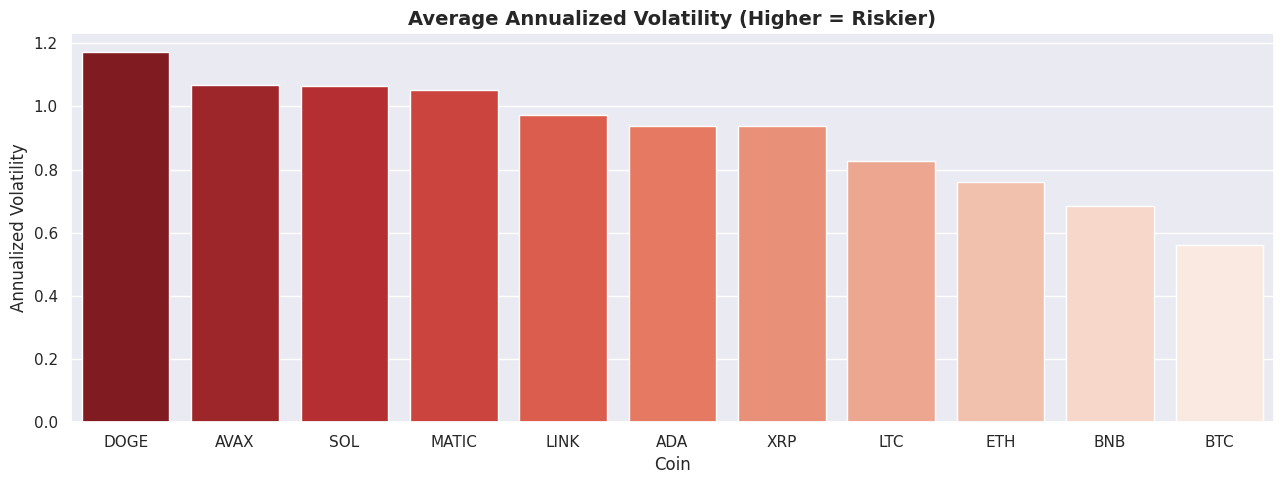

     Coin  Annualized Volatility
0    DOGE               1.172933
1    AVAX               1.068472
2     SOL               1.064391
3   MATIC               1.050636
4    LINK               0.973236
5     ADA               0.939513
6     XRP               0.936745
7     LTC               0.828270
8     ETH               0.760000
9     BNB               0.684861
10    BTC               0.561815


In [9]:
avg_vol = (returns.std() * np.sqrt(365)).sort_values(ascending=False).reset_index()
avg_vol.columns = ['Coin','Annualized Volatility']

plt.figure(figsize=(13, 5))
sns.barplot(data=avg_vol, x='Coin', y='Annualized Volatility', palette='Reds_r')
plt.title('Average Annualized Volatility (Higher = Riskier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(avg_vol.to_string())

## 6. Moving Averages

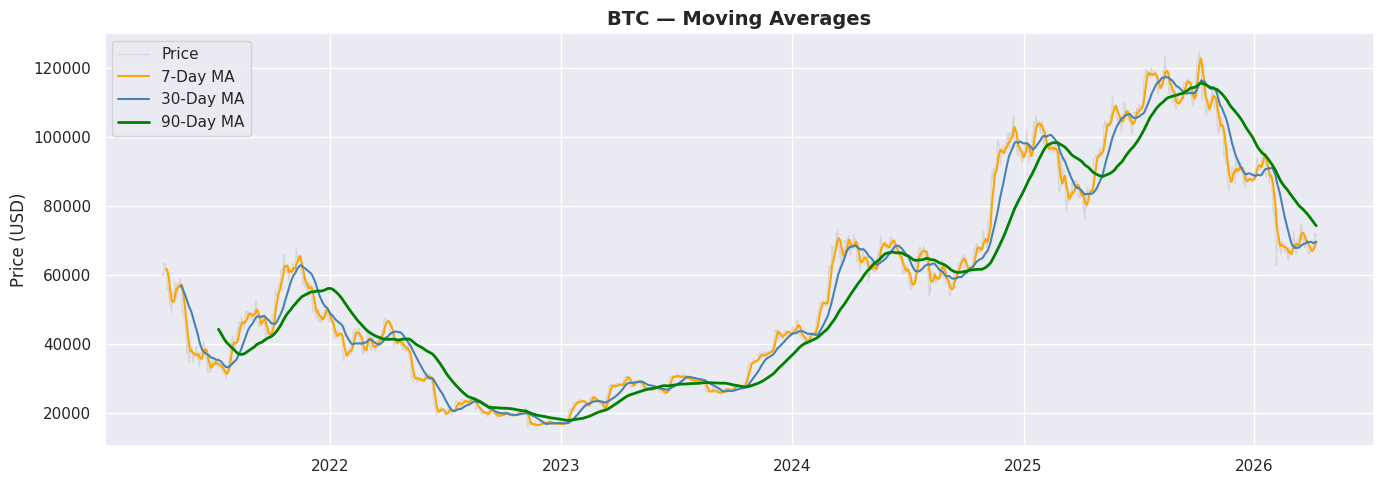

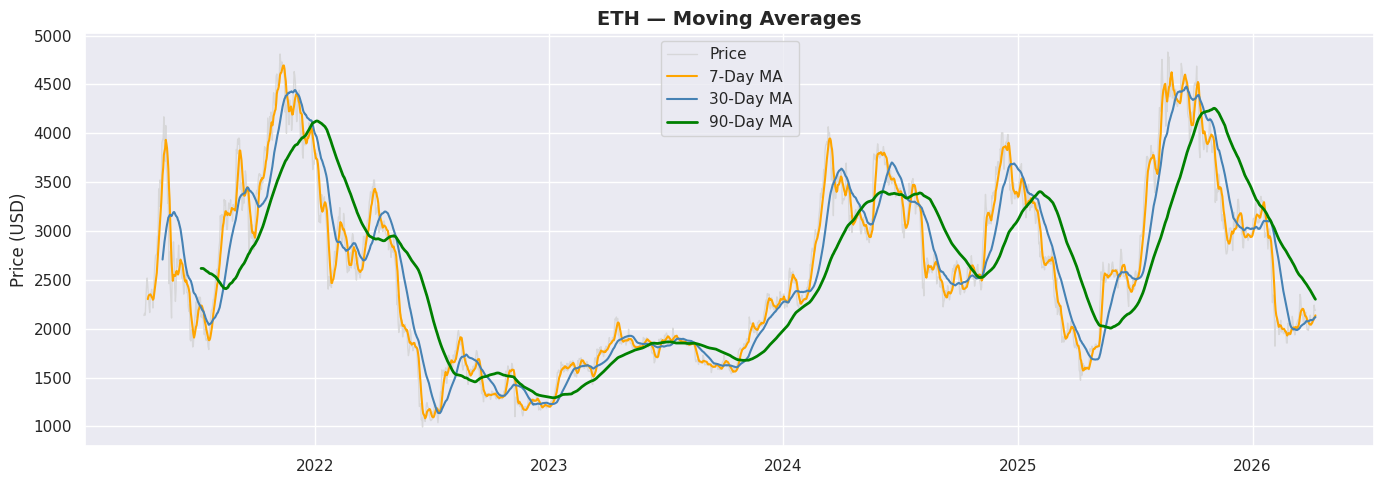

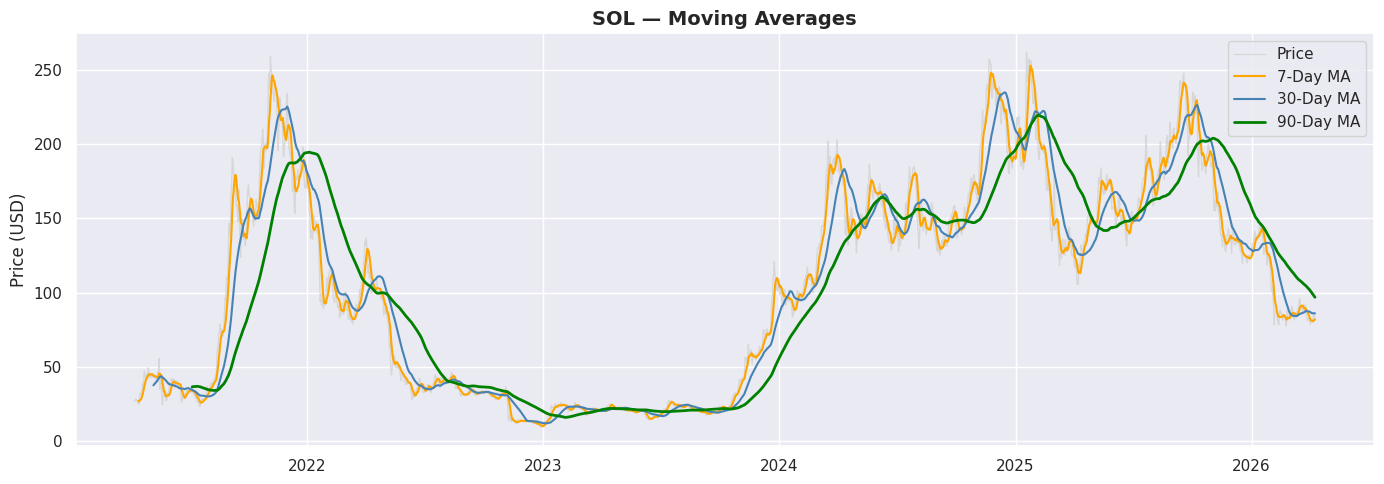

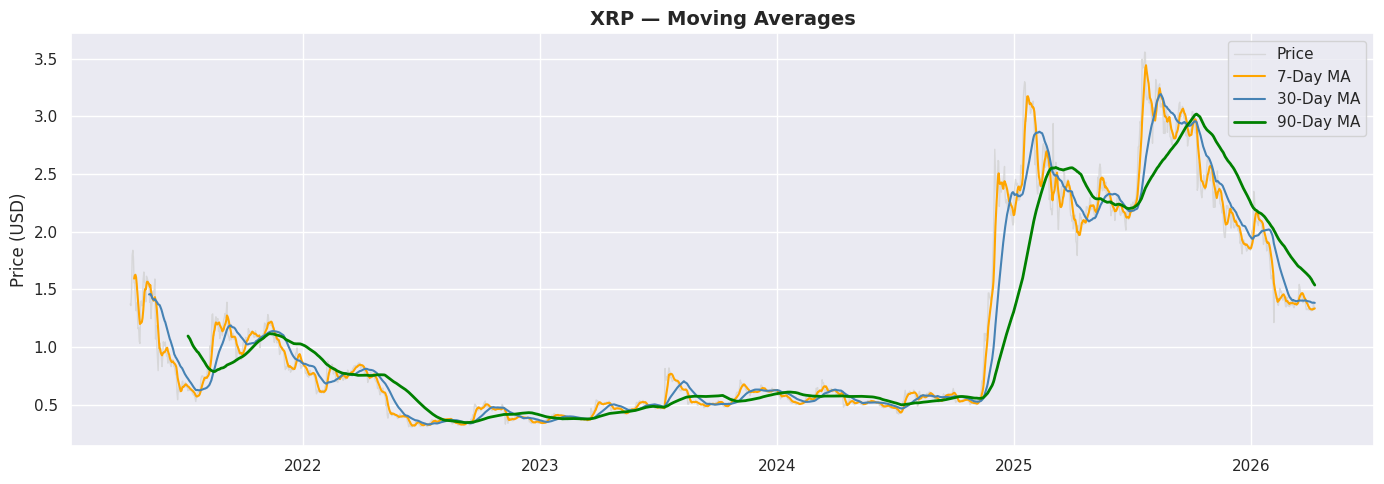

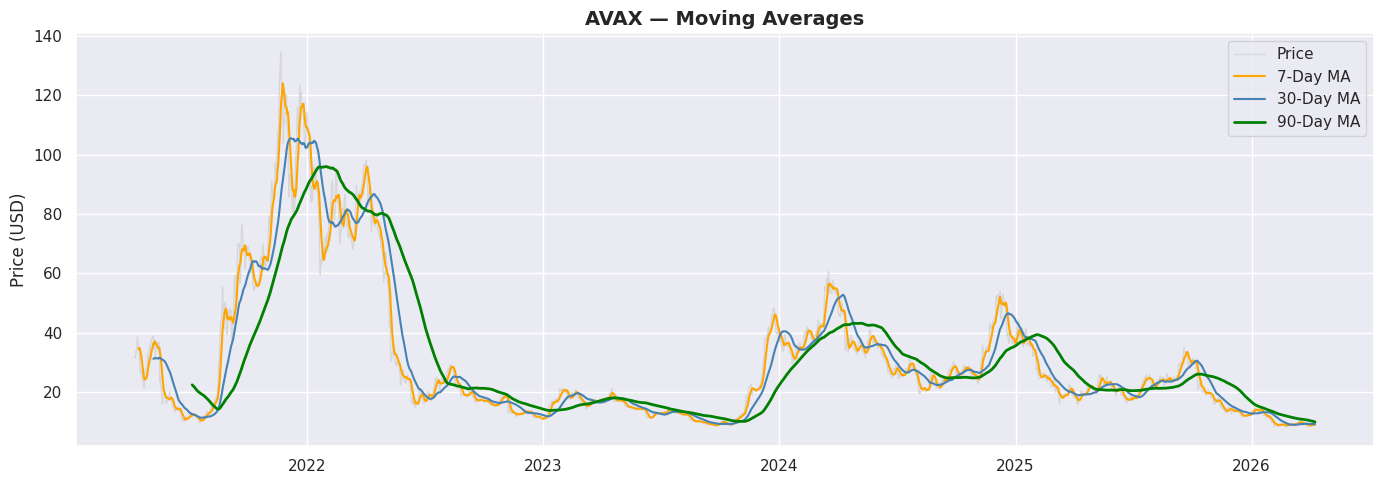

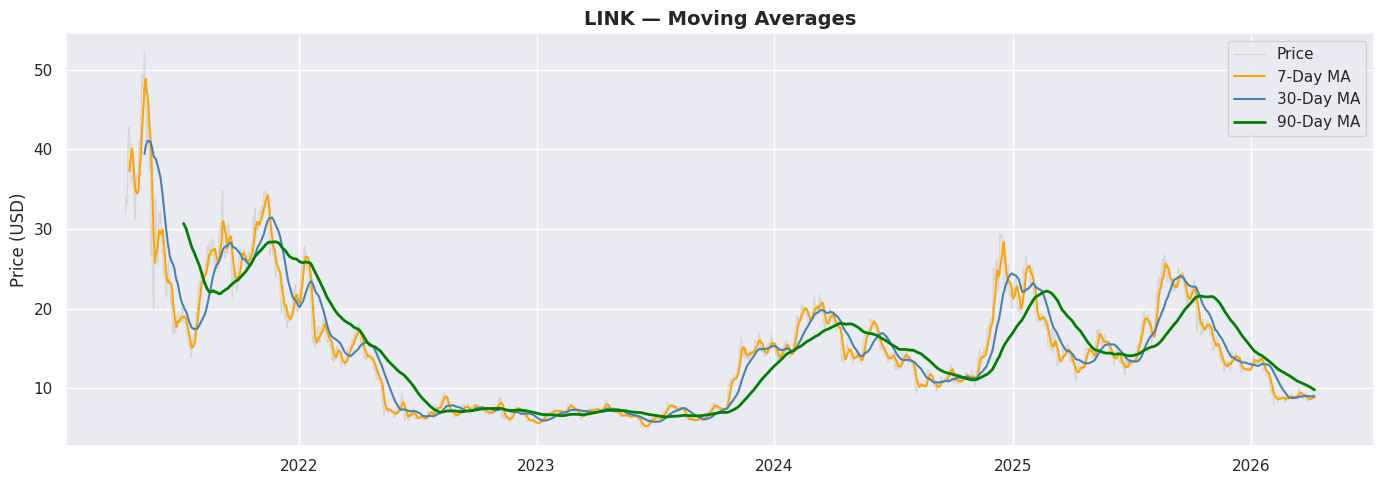

In [10]:
def plot_moving_averages(coin):
    if coin not in prices.columns: return
    col  = prices[coin].dropna()
    ma7  = col.rolling(7).mean()
    ma30 = col.rolling(30).mean()
    ma90 = col.rolling(90).mean()
    plt.figure(figsize=(14, 5))
    plt.plot(col.index,  col.values,  label='Price',     color='lightgray', linewidth=1,   alpha=0.8)
    plt.plot(ma7.index,  ma7.values,  label='7-Day MA',  color='orange',    linewidth=1.5)
    plt.plot(ma30.index, ma30.values, label='30-Day MA', color='steelblue', linewidth=1.5)
    plt.plot(ma90.index, ma90.values, label='90-Day MA', color='green',     linewidth=2)
    plt.title(f'{coin} — Moving Averages', fontsize=14, fontweight='bold')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

for c in ['BTC','ETH','SOL','XRP','AVAX','LINK']:
    plot_moving_averages(c)

## 7. Bollinger Bands

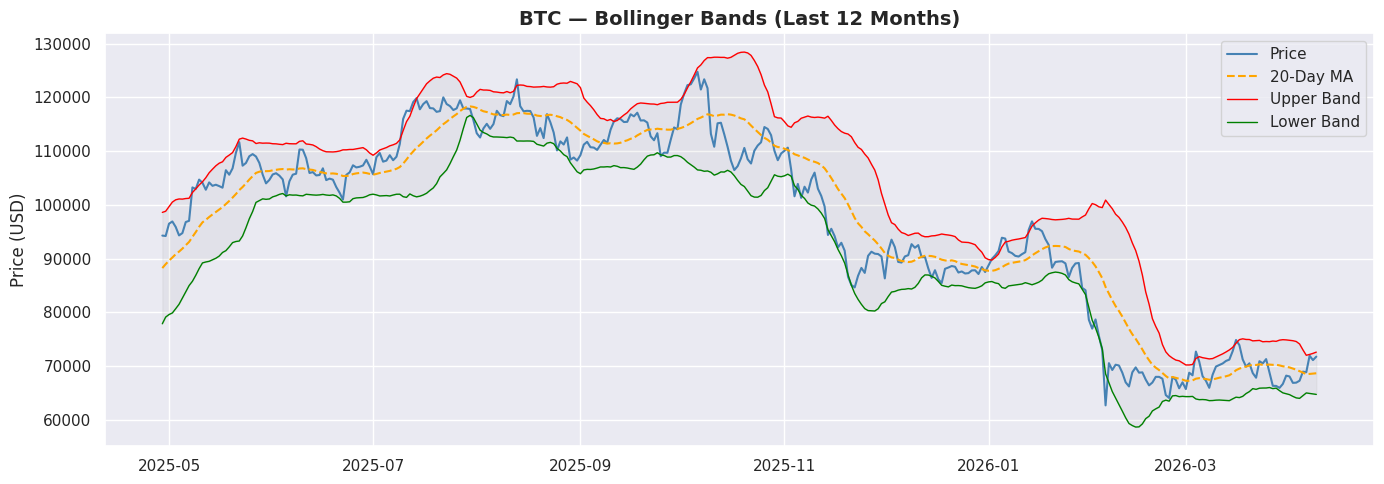

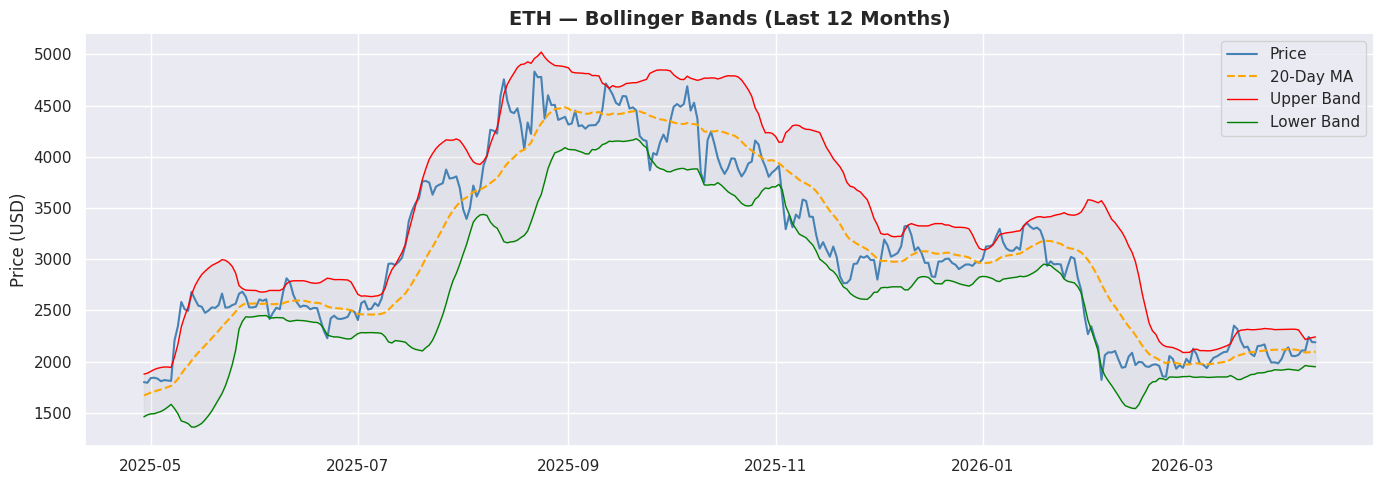

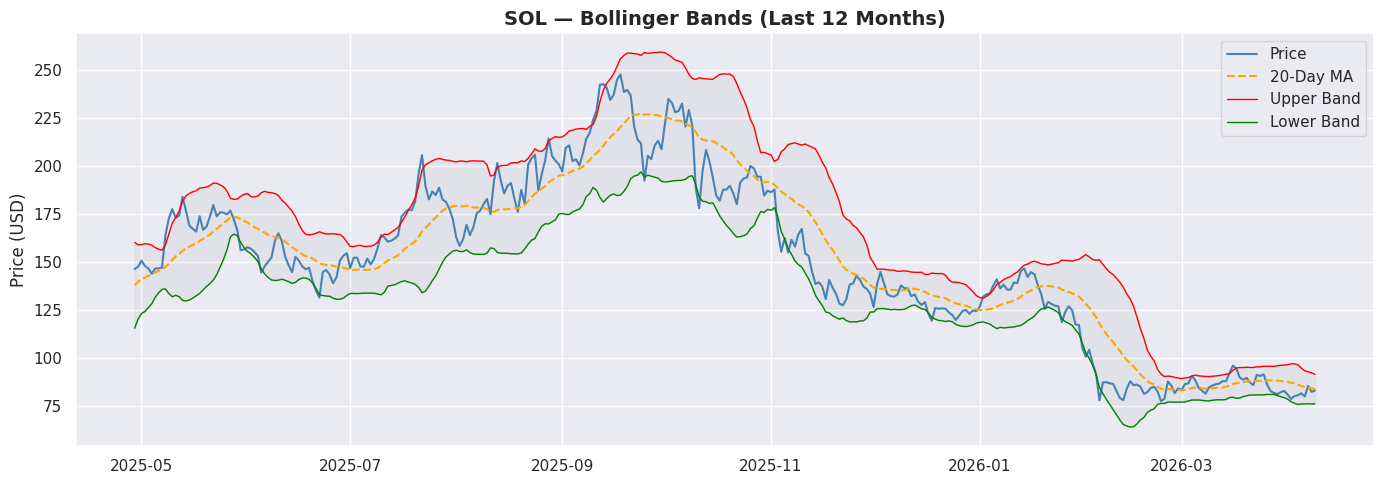

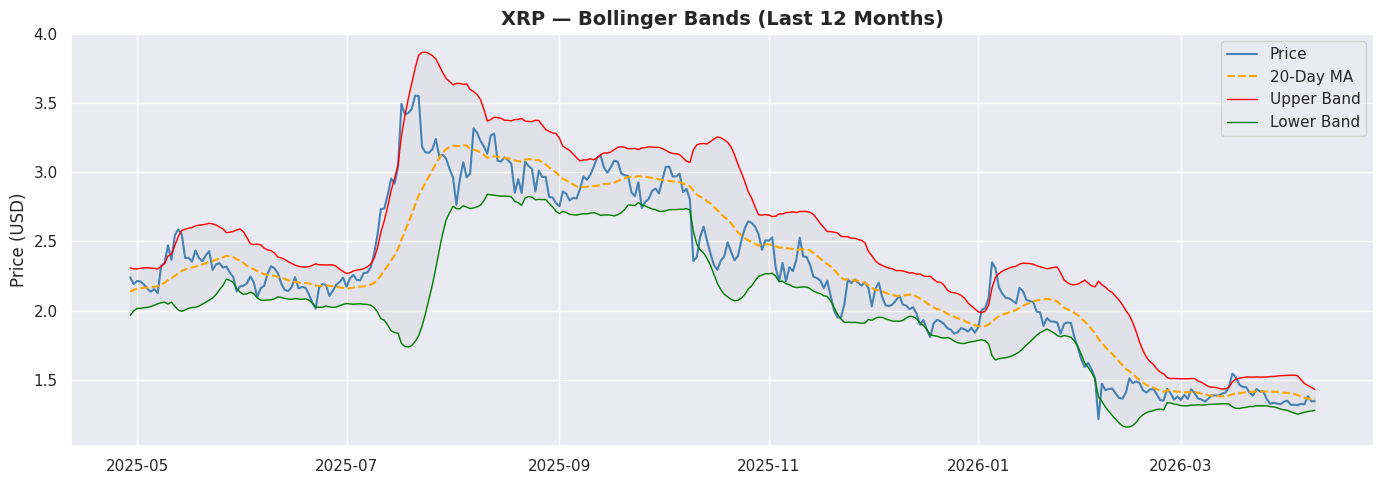

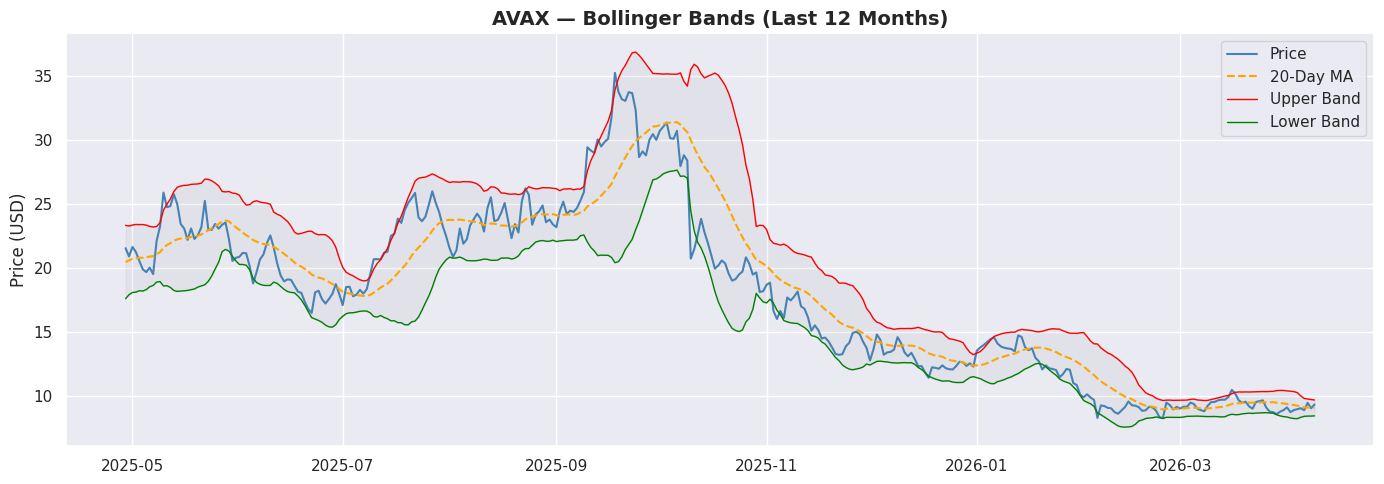

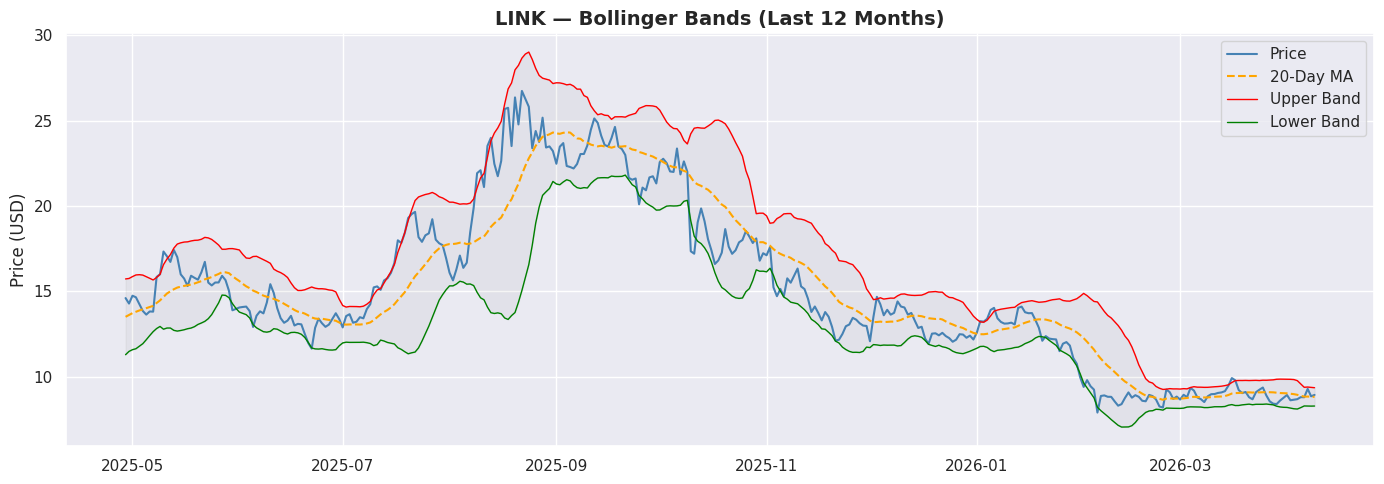

In [11]:
def plot_bollinger(coin, window=20):
    if coin not in prices.columns: return
    col   = prices[coin].dropna().last('365D')
    ma    = col.rolling(window).mean()
    std   = col.rolling(window).std()
    upper = (ma + 2 * std).dropna()
    lower = (ma - 2 * std).dropna()
    ma    = ma.dropna()
    col   = col.loc[ma.index]
    plt.figure(figsize=(14, 5))
    plt.plot(col.index,   col.values,   label='Price',      color='steelblue', linewidth=1.5)
    plt.plot(ma.index,    ma.values,    label='20-Day MA',  color='orange',    linewidth=1.5, linestyle='--')
    plt.plot(upper.index, upper.values, label='Upper Band', color='red',       linewidth=1)
    plt.plot(lower.index, lower.values, label='Lower Band', color='green',     linewidth=1)
    plt.fill_between(upper.index, upper.values, lower.values, alpha=0.08, color='gray')
    plt.title(f'{coin} — Bollinger Bands (Last 12 Months)', fontsize=14, fontweight='bold')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

for c in ['BTC','ETH','SOL','XRP','AVAX','LINK']:
    plot_bollinger(c)

## 8. RSI — Relative Strength Index

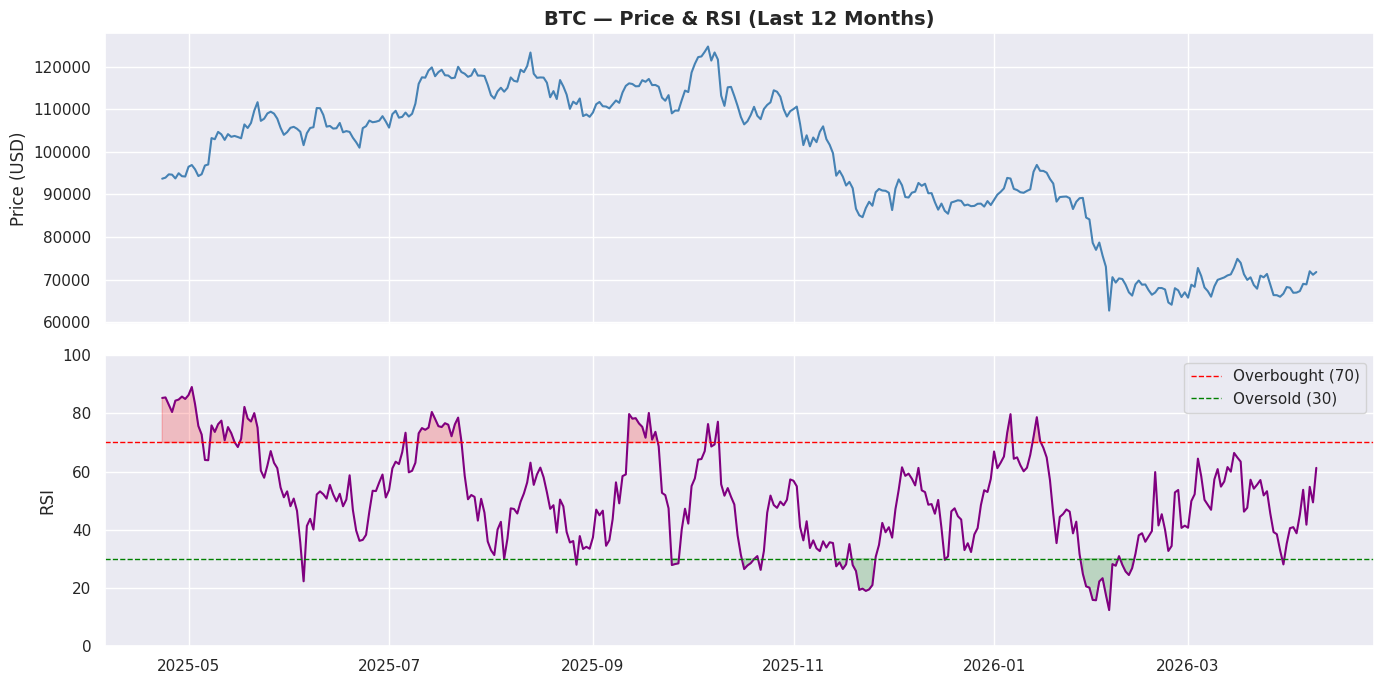

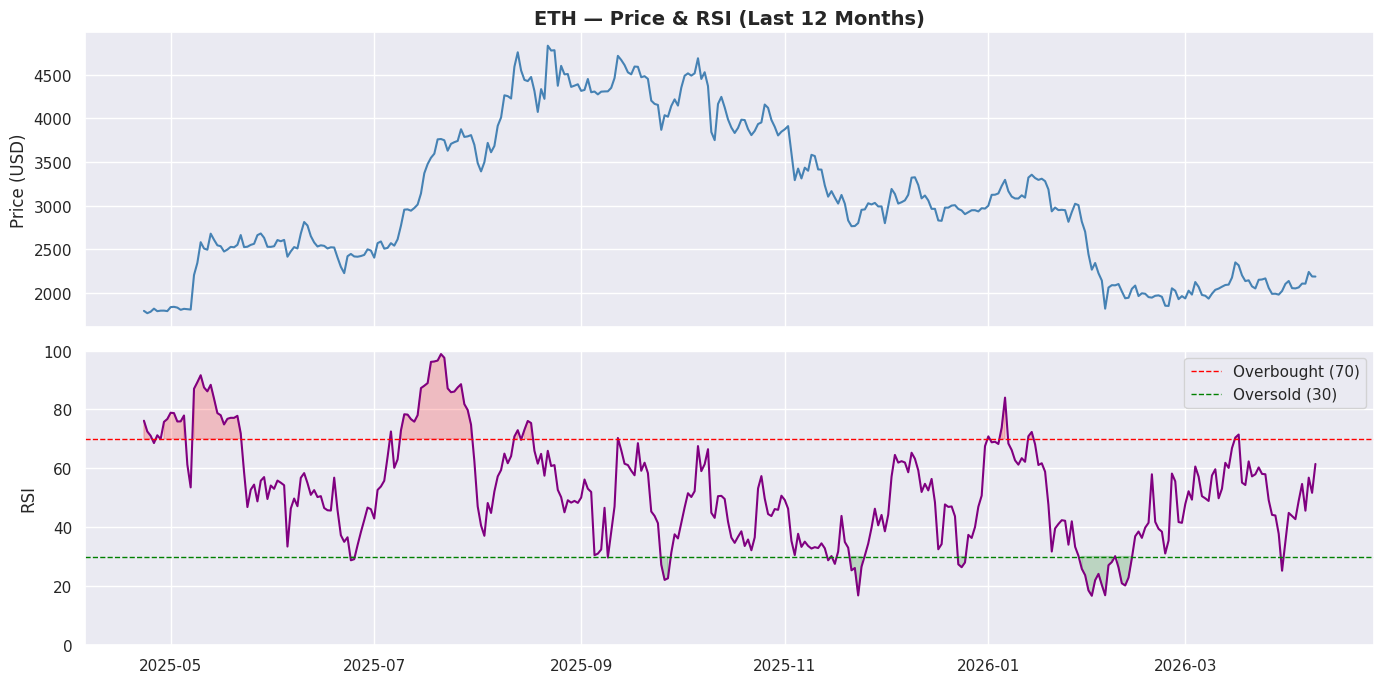

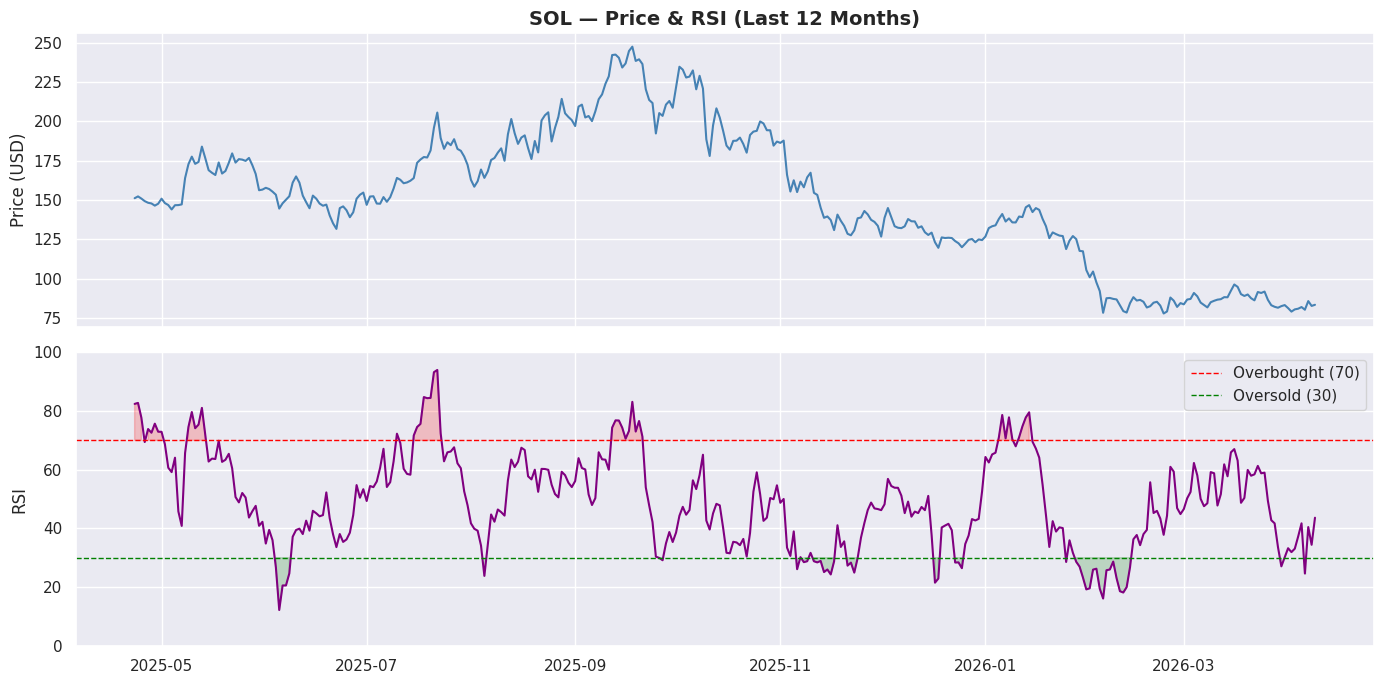

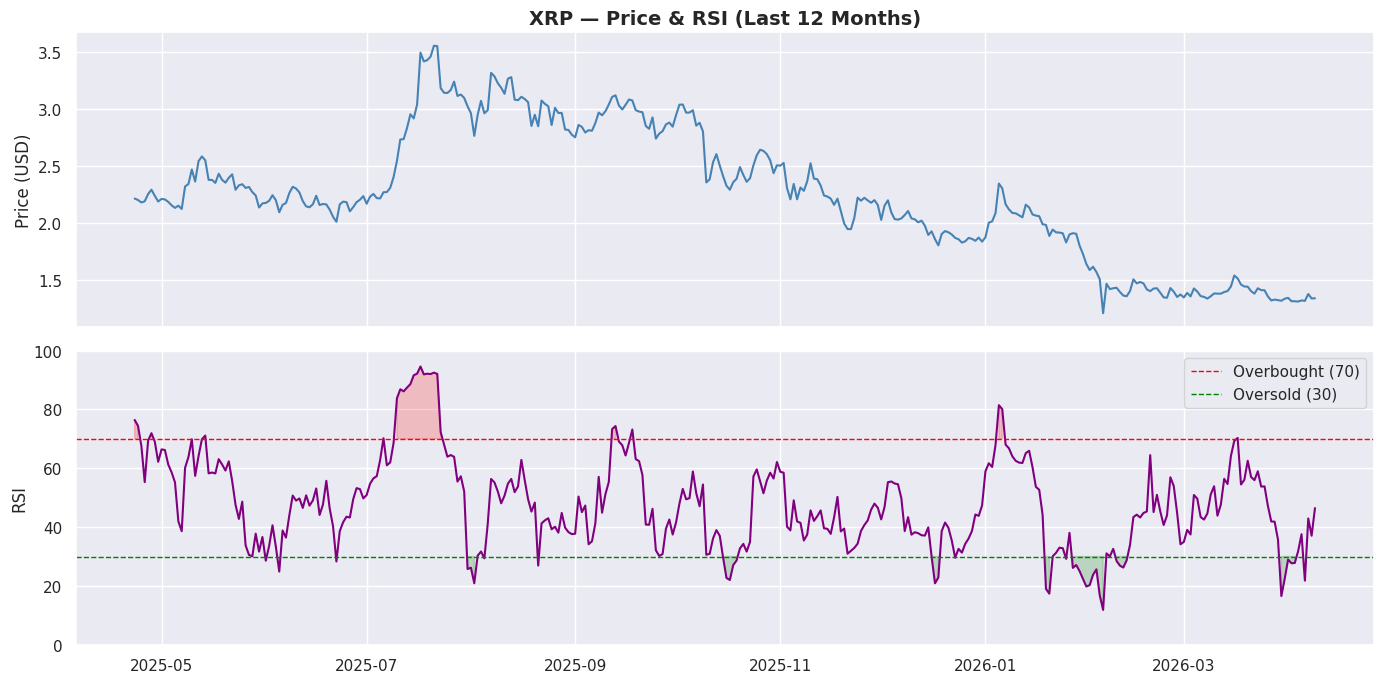

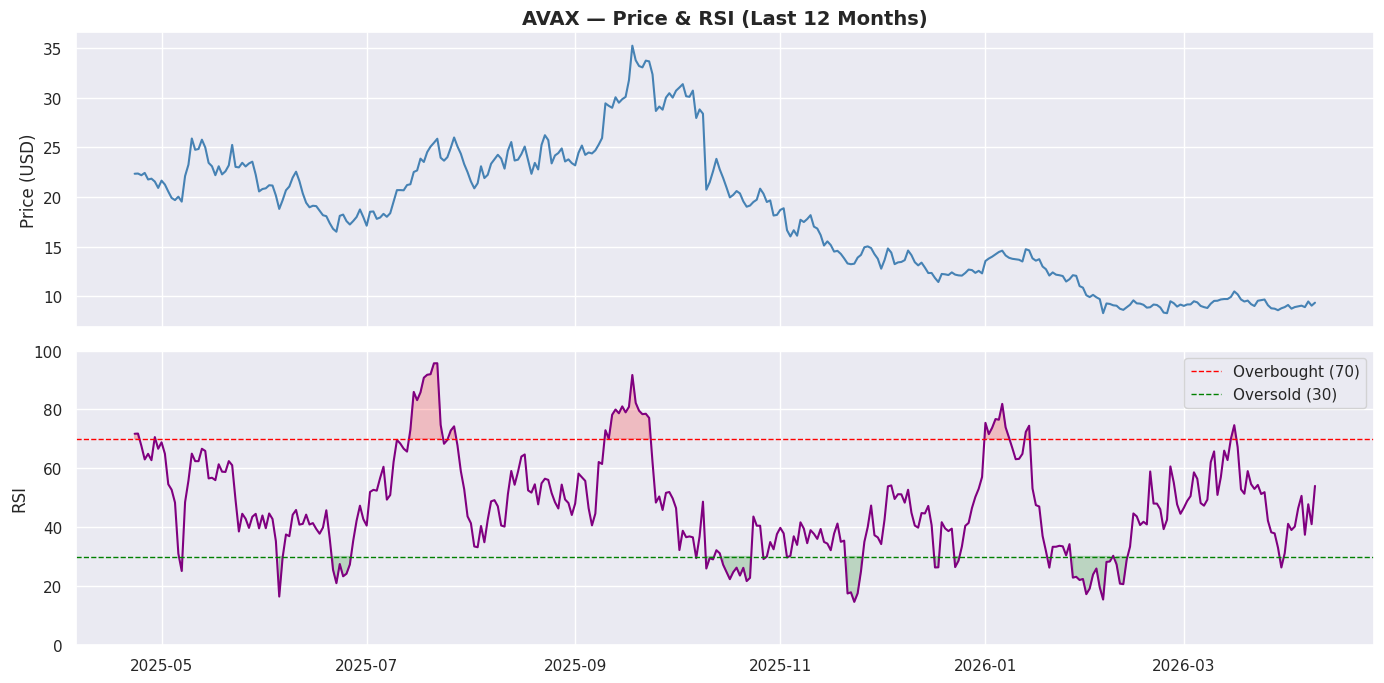

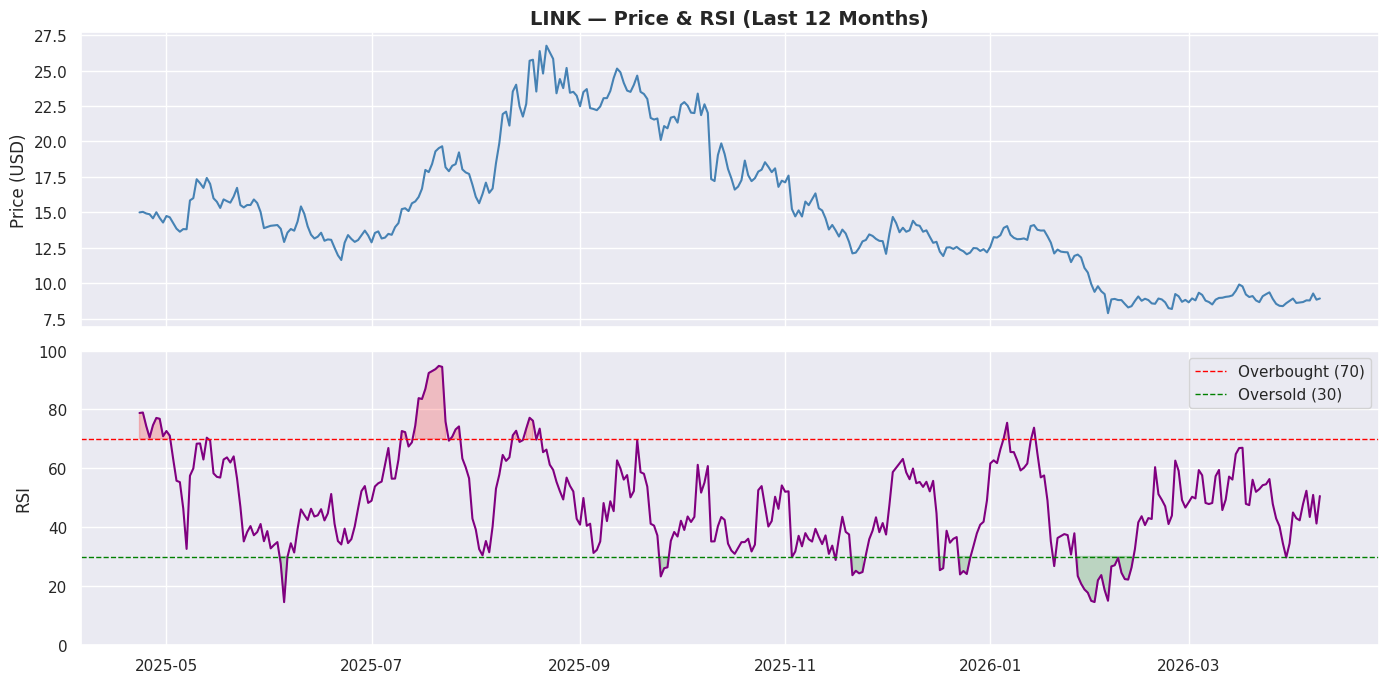

In [12]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0).rolling(period).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(period).mean()
    return 100 - (100 / (1 + gain / loss))

def plot_rsi(coin):
    if coin not in prices.columns: return
    col   = prices[coin].dropna().last('365D')
    rsi   = calculate_rsi(col).dropna()
    price = col.loc[rsi.index]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    ax1.plot(price.index, price.values, color='steelblue', linewidth=1.5)
    ax1.set_title(f'{coin} — Price & RSI (Last 12 Months)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (USD)')
    rsi_vals = rsi.values
    ax2.plot(rsi.index, rsi_vals, color='purple', linewidth=1.5)
    ax2.axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
    ax2.axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
    ax2.fill_between(rsi.index, rsi_vals, 70, where=(rsi_vals >= 70), alpha=0.2, color='red')
    ax2.fill_between(rsi.index, rsi_vals, 30, where=(rsi_vals <= 30), alpha=0.2, color='green')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI')
    ax2.legend()
    plt.tight_layout()
    plt.show()

for c in ['BTC','ETH','SOL','XRP','AVAX','LINK']:
    plot_rsi(c)

## 9. Correlation Matrix

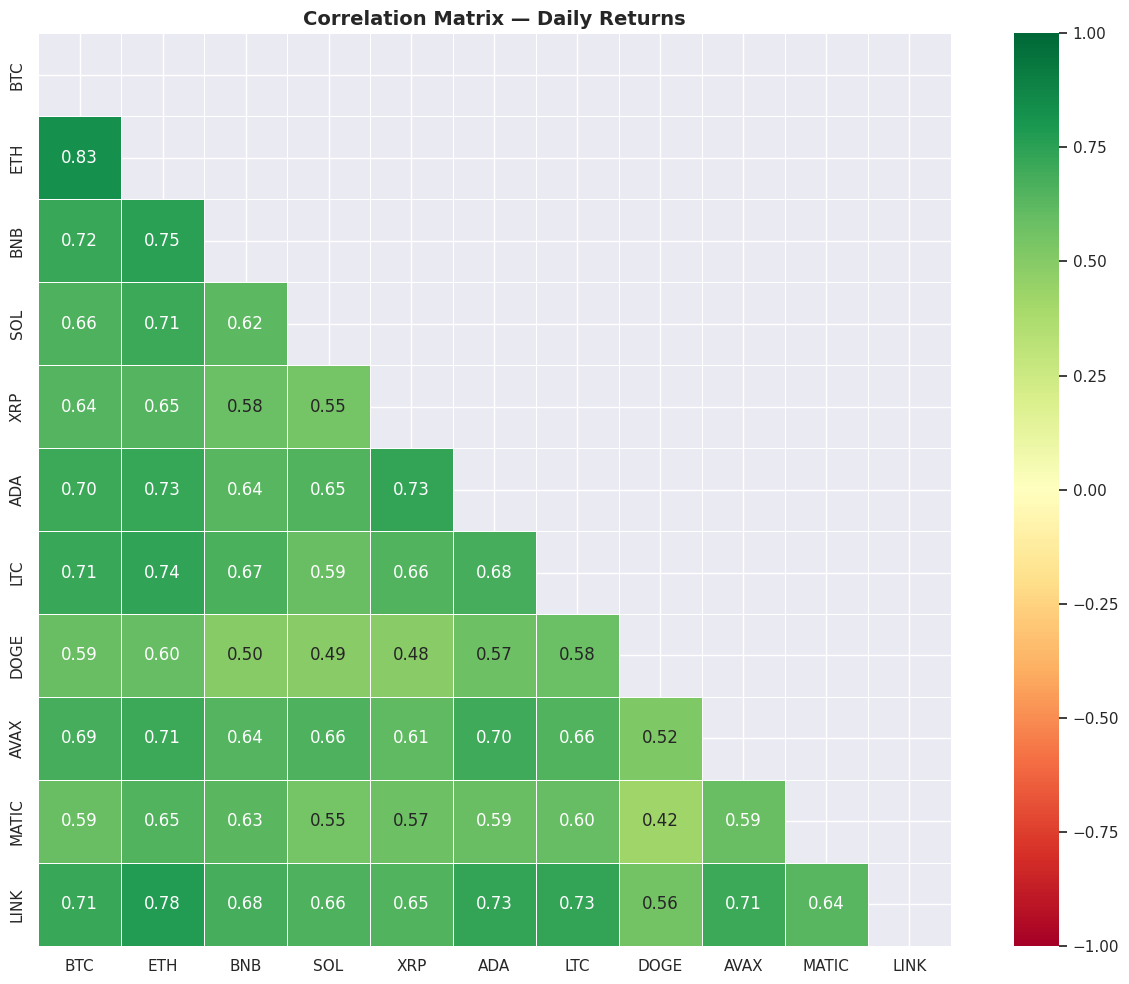

In [13]:
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Daily Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

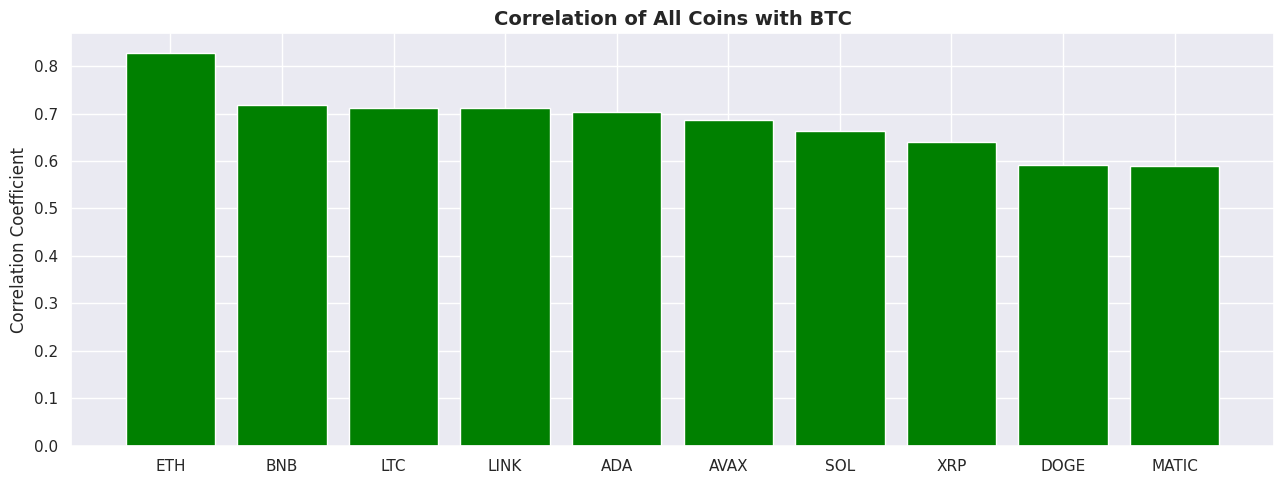

In [14]:
if 'BTC' in returns.columns:
    btc_corr   = returns.corrwith(returns['BTC']).drop('BTC').sort_values(ascending=False)
    bar_colors = ['green' if x > 0 else 'red' for x in btc_corr.values]
    plt.figure(figsize=(13, 5))
    plt.bar(btc_corr.index, btc_corr.values, color=bar_colors, edgecolor='white')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title('Correlation of All Coins with BTC', fontsize=14, fontweight='bold')
    plt.ylabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()

## 10. Monthly Returns Heatmap

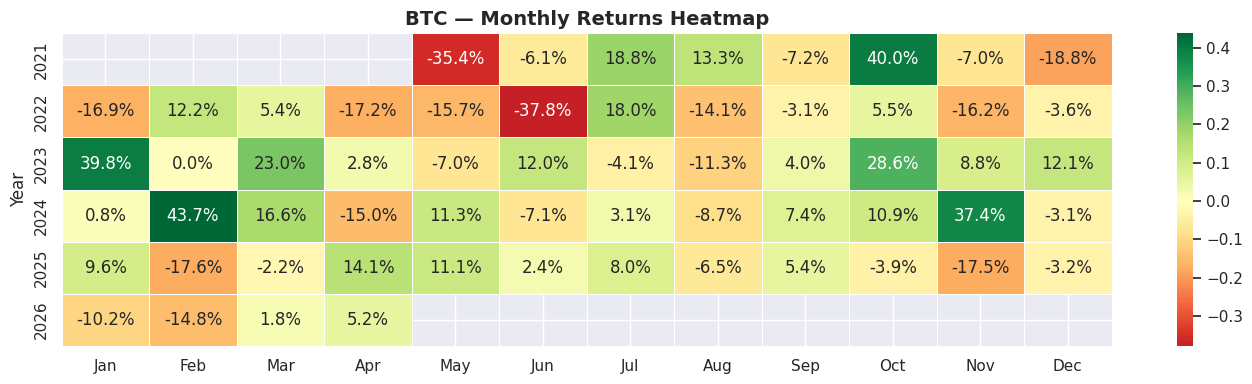

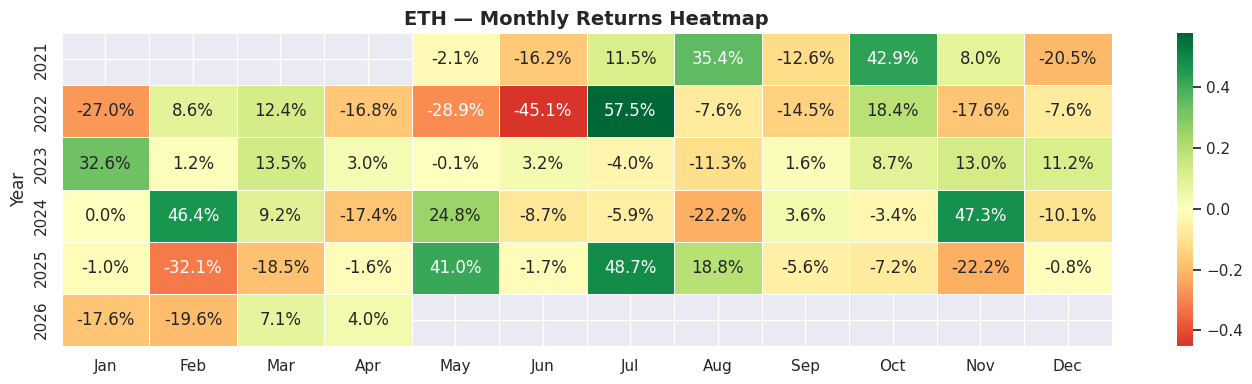

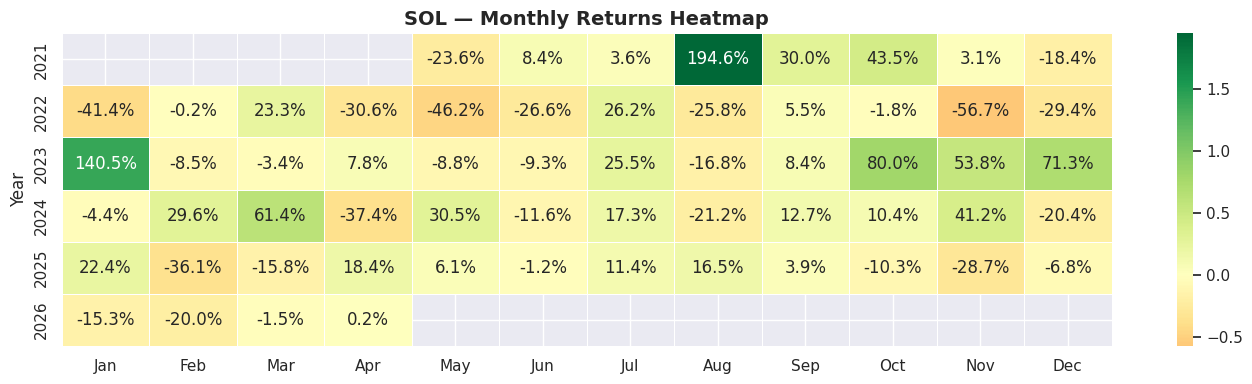

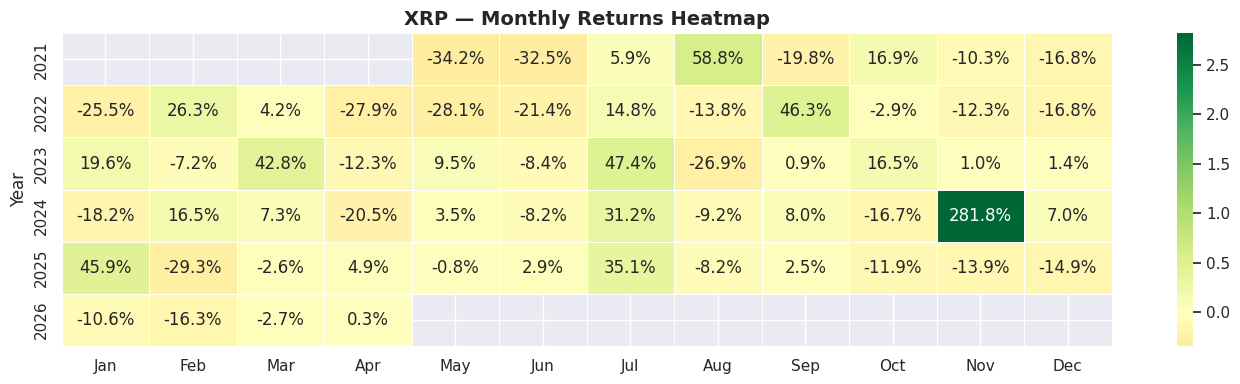

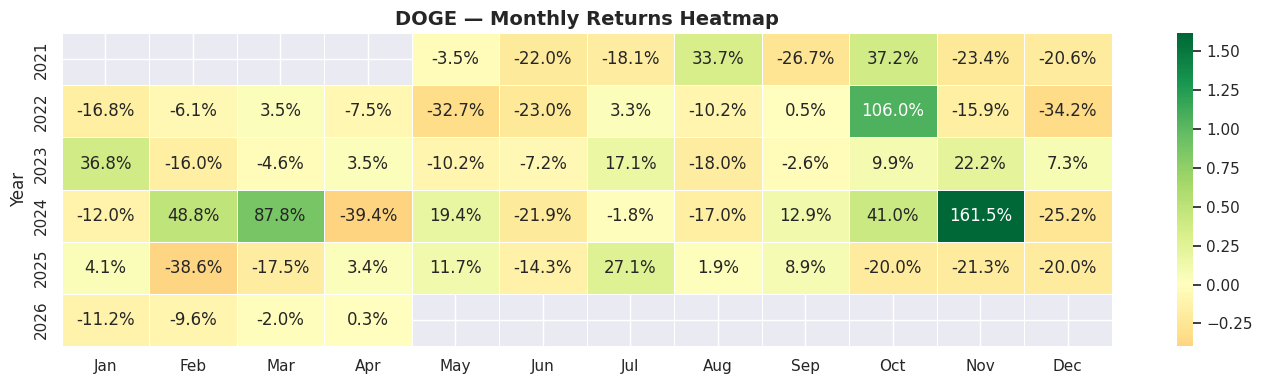

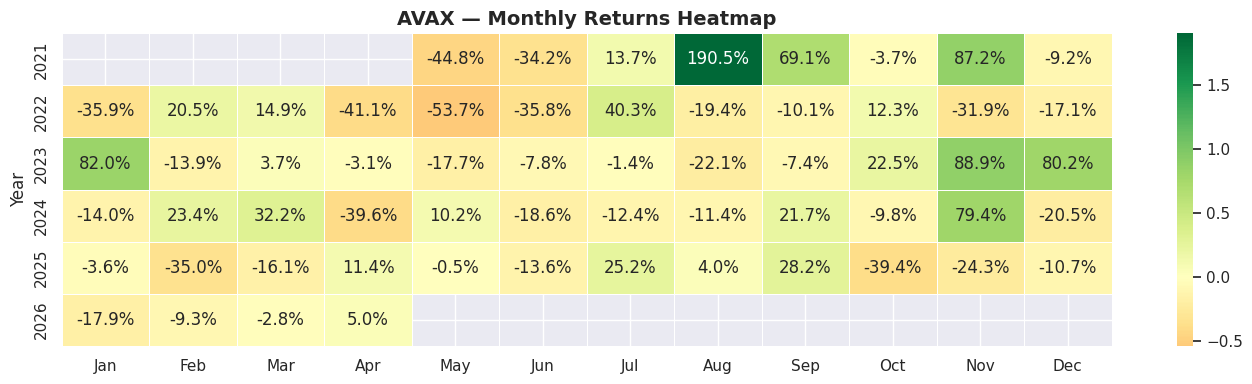

In [15]:
def plot_monthly_heatmap(coin):
    if coin not in prices.columns: return
    col     = prices[coin].dropna()
    monthly = col.resample('ME').last().pct_change().dropna()
    df_m    = pd.DataFrame({'ret': monthly.values, 'Year': monthly.index.year, 'Month': monthly.index.month})
    pivot   = df_m.pivot(index='Year', columns='Month', values='ret')
    labels  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    pivot.columns = [labels[m-1] for m in pivot.columns]
    plt.figure(figsize=(14, 4))
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0, linewidths=0.5)
    plt.title(f'{coin} — Monthly Returns Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

for c in ['BTC','ETH','SOL','XRP','DOGE','AVAX']:
    plot_monthly_heatmap(c)

## 11. Drawdown Analysis

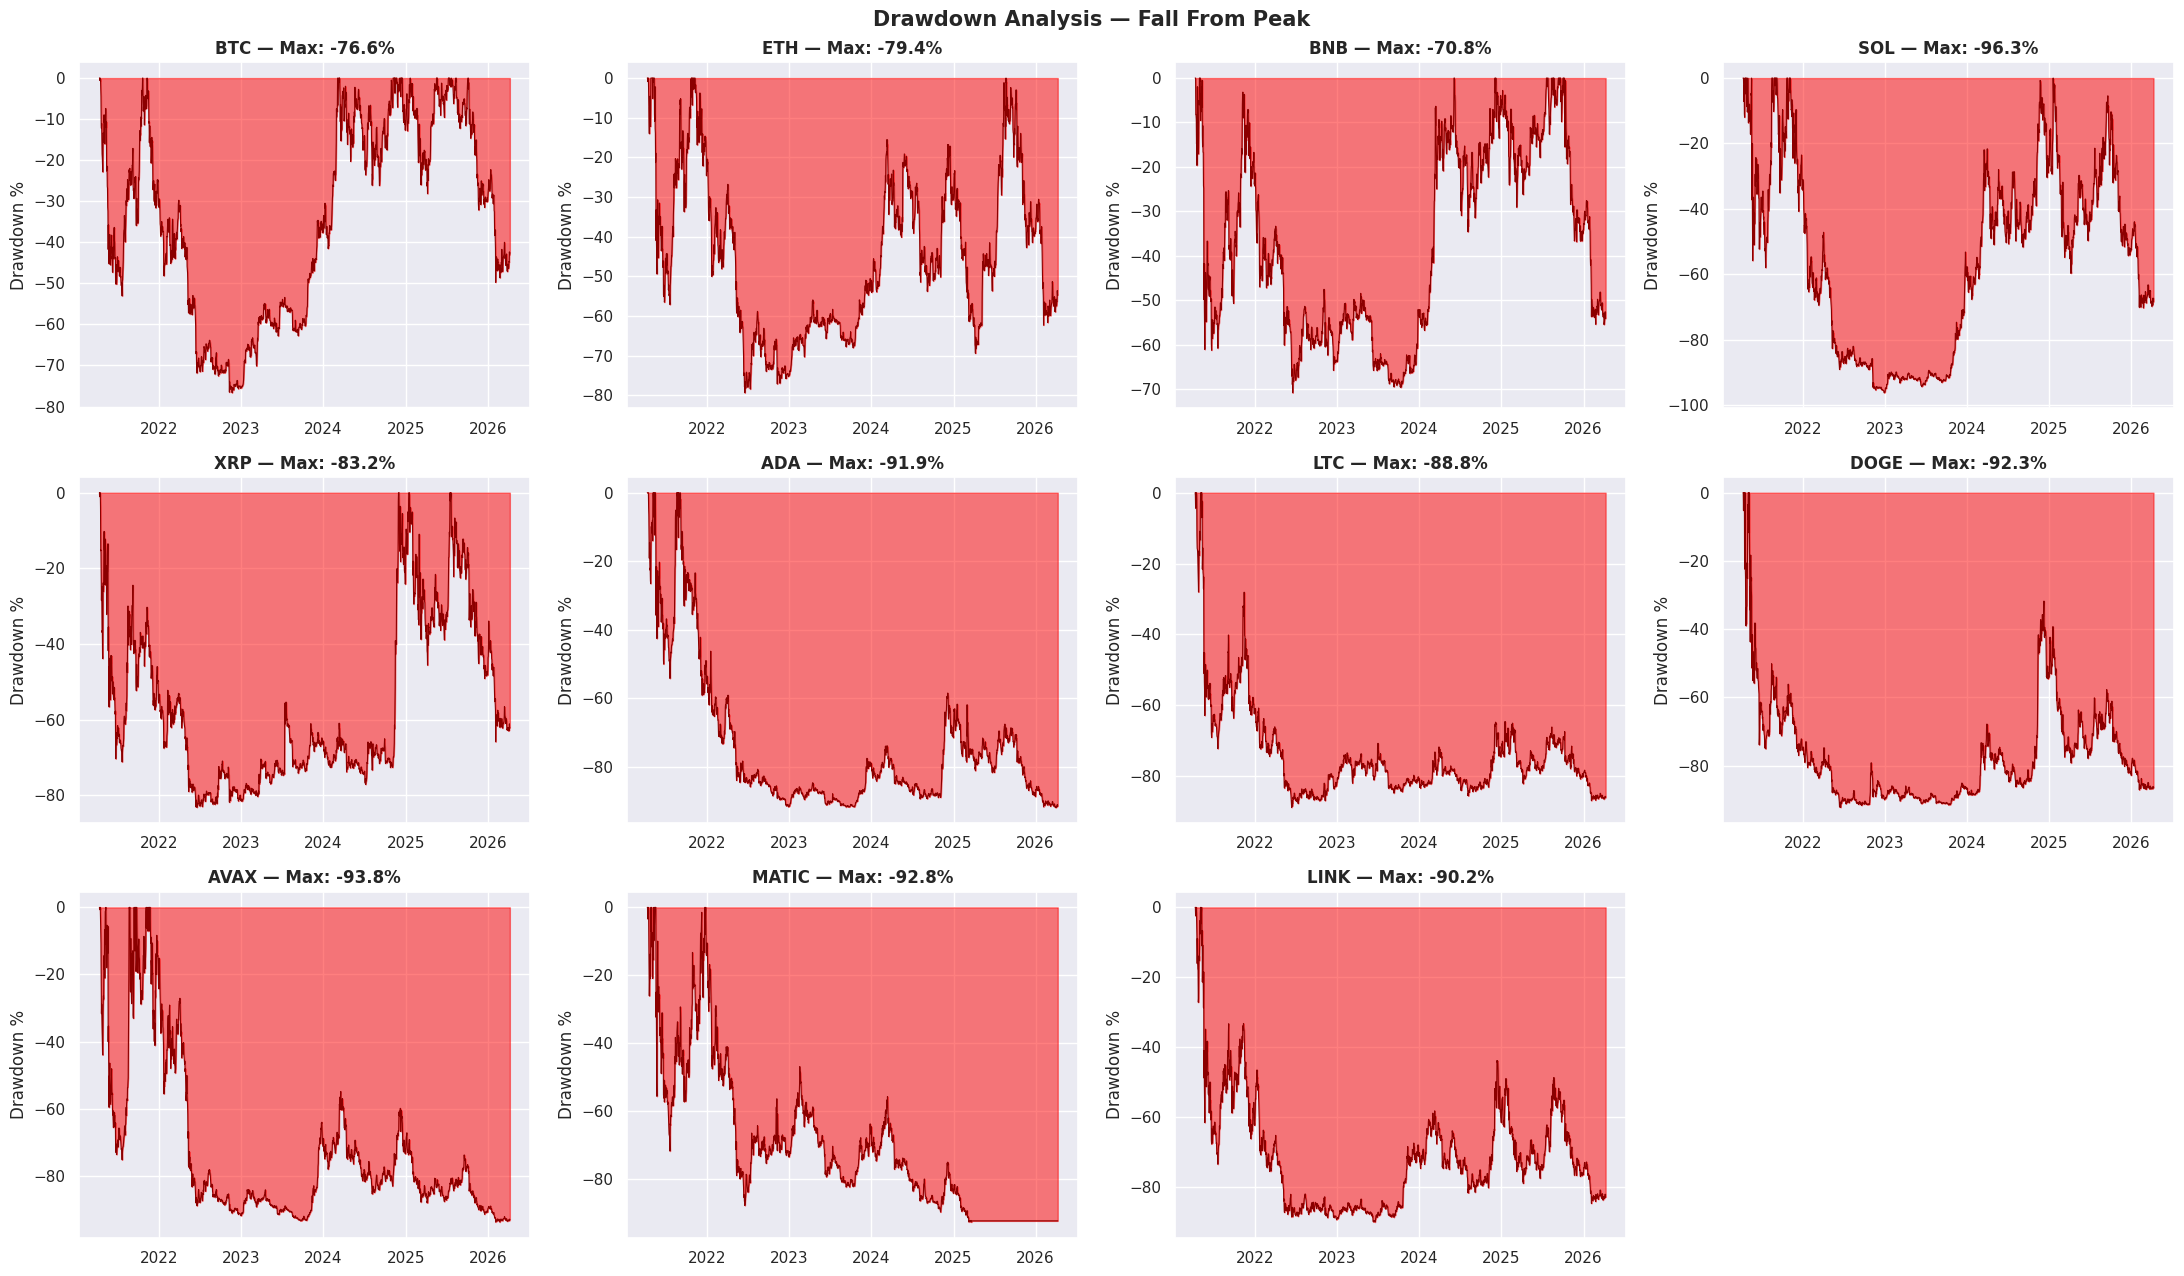

In [16]:
def get_drawdown(series):
    return (series - series.cummax()) / series.cummax()

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
axes = axes.flatten()

for i, coin in enumerate(prices.columns):
    col = prices[coin].dropna()
    dd  = get_drawdown(col)
    axes[i].fill_between(dd.index, dd.values * 100, 0, color='red', alpha=0.5)
    axes[i].plot(dd.index, dd.values * 100, color='darkred', linewidth=0.8)
    axes[i].set_title(f'{coin} — Max: {dd.min()*100:.1f}%', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Drawdown %')

for j in range(len(prices.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Drawdown Analysis — Fall From Peak', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

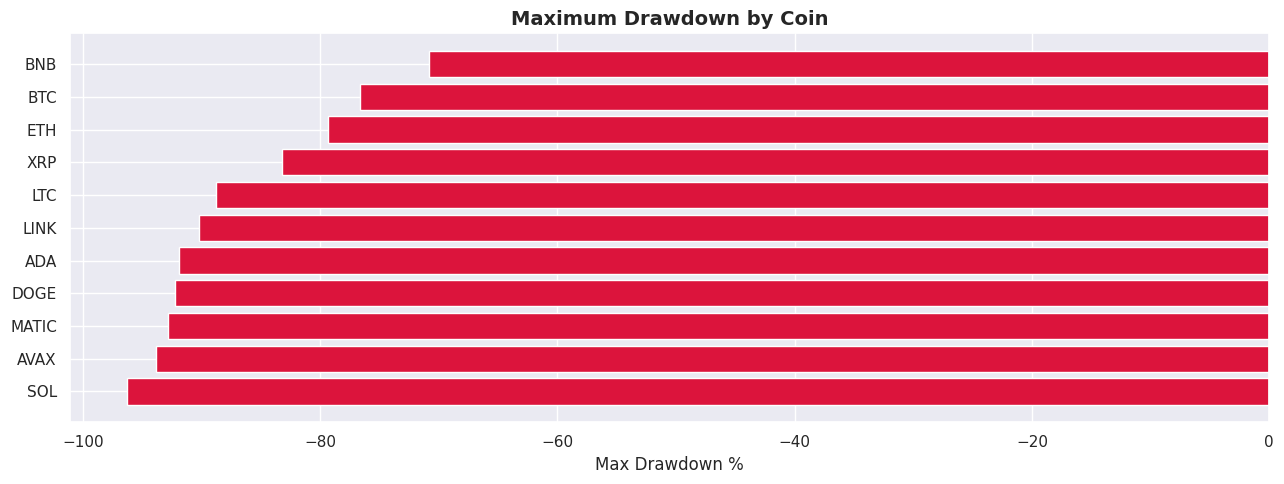

     Coin  Max Drawdown %
0     SOL      -96.272498
1    AVAX      -93.834092
2   MATIC      -92.828522
3    DOGE      -92.258502
4     ADA      -91.936027
5    LINK      -90.192943
6     LTC      -88.795390
7     XRP      -83.249023
8     ETH      -79.351232
9     BTC      -76.634564
10    BNB      -70.837999


In [17]:
dd_summary = {c: get_drawdown(prices[c].dropna()).min() * 100 for c in prices.columns}
dd_df = pd.Series(dd_summary).sort_values().reset_index()
dd_df.columns = ['Coin','Max Drawdown %']
plt.figure(figsize=(13, 5))
plt.barh(dd_df['Coin'], dd_df['Max Drawdown %'], color='crimson', edgecolor='white')
plt.title('Maximum Drawdown by Coin', fontsize=14, fontweight='bold')
plt.xlabel('Max Drawdown %')
plt.tight_layout()
plt.show()
print(dd_df.to_string())

## 12. Sharpe Ratio

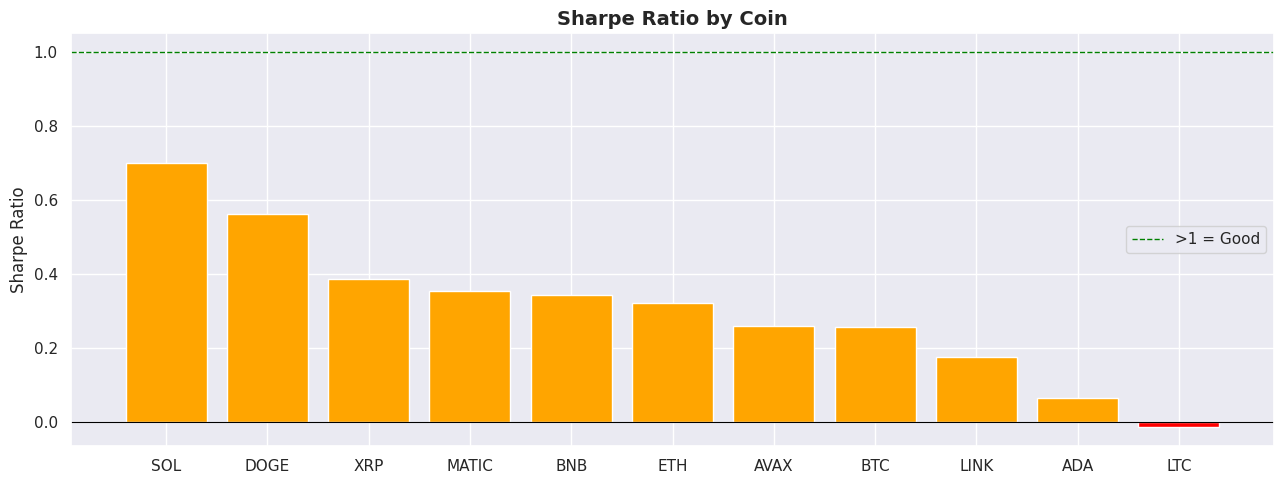

     Coin  Sharpe Ratio
0     SOL      0.700488
1    DOGE      0.561232
2     XRP      0.386699
3   MATIC      0.353438
4     BNB      0.344729
5     ETH      0.320837
6    AVAX      0.260210
7     BTC      0.257353
8    LINK      0.176146
9     ADA      0.064210
10    LTC     -0.013383


In [18]:
RF = 0.05 / 365
sharpe = {}
for c in returns.columns:
    r = returns[c].dropna()
    if len(r) > 10:
        sharpe[c] = ((r.mean() - RF) / r.std()) * np.sqrt(365)

sharpe_df = pd.Series(sharpe).sort_values(ascending=False).reset_index()
sharpe_df.columns = ['Coin','Sharpe Ratio']
bar_colors = ['green' if x > 1 else 'orange' if x > 0 else 'red' for x in sharpe_df['Sharpe Ratio']]
plt.figure(figsize=(13, 5))
plt.bar(sharpe_df['Coin'], sharpe_df['Sharpe Ratio'], color=bar_colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(1, color='green', linewidth=1, linestyle='--', label='>1 = Good')
plt.title('Sharpe Ratio by Coin', fontsize=14, fontweight='bold')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.show()
print(sharpe_df.to_string())

## 13. Total Returns

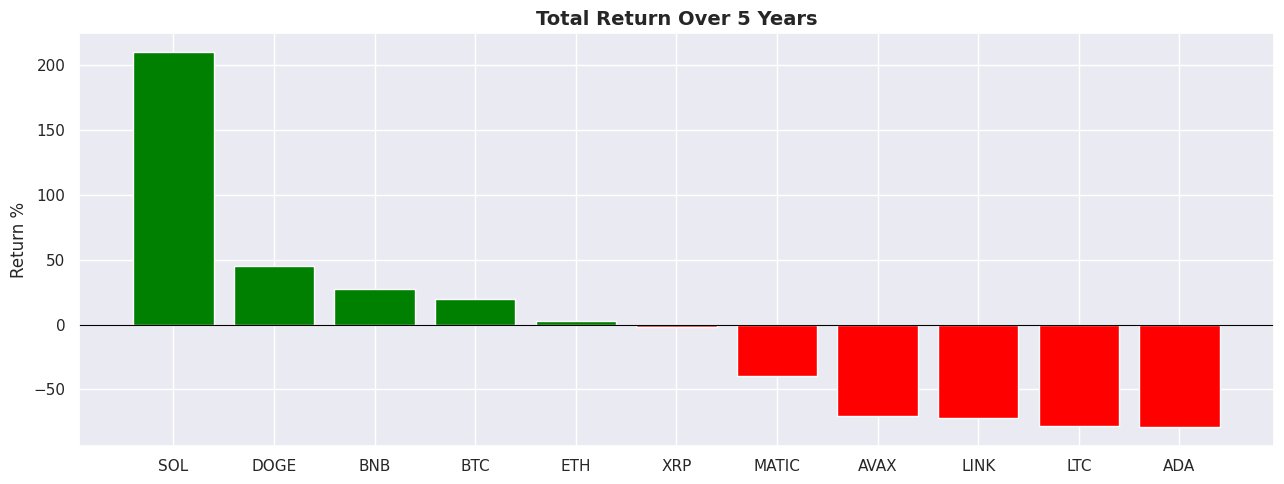

     Coin  Total Return %
0     SOL      210.332983
1    DOGE       44.929118
2     BNB       27.566254
3     BTC       20.026670
4     ETH        2.490793
5     XRP       -2.202536
6   MATIC      -39.628310
7    AVAX      -70.596492
8    LINK      -71.965589
9     LTC      -78.678334
10    ADA      -79.174044


In [19]:
total_ret = {}
for c in prices.columns:
    col = prices[c].dropna()
    if len(col) > 1:
        total_ret[c] = ((col.iloc[-1] - col.iloc[0]) / col.iloc[0]) * 100

tr_df = pd.Series(total_ret).sort_values(ascending=False).reset_index()
tr_df.columns = ['Coin','Total Return %']
bar_colors = ['green' if x > 0 else 'red' for x in tr_df['Total Return %']]
plt.figure(figsize=(13, 5))
plt.bar(tr_df['Coin'], tr_df['Total Return %'], color=bar_colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Total Return Over 5 Years', fontsize=14, fontweight='bold')
plt.ylabel('Return %')
plt.tight_layout()
plt.show()
print(tr_df.to_string())

## 14. Portfolio Simulation — $1,000

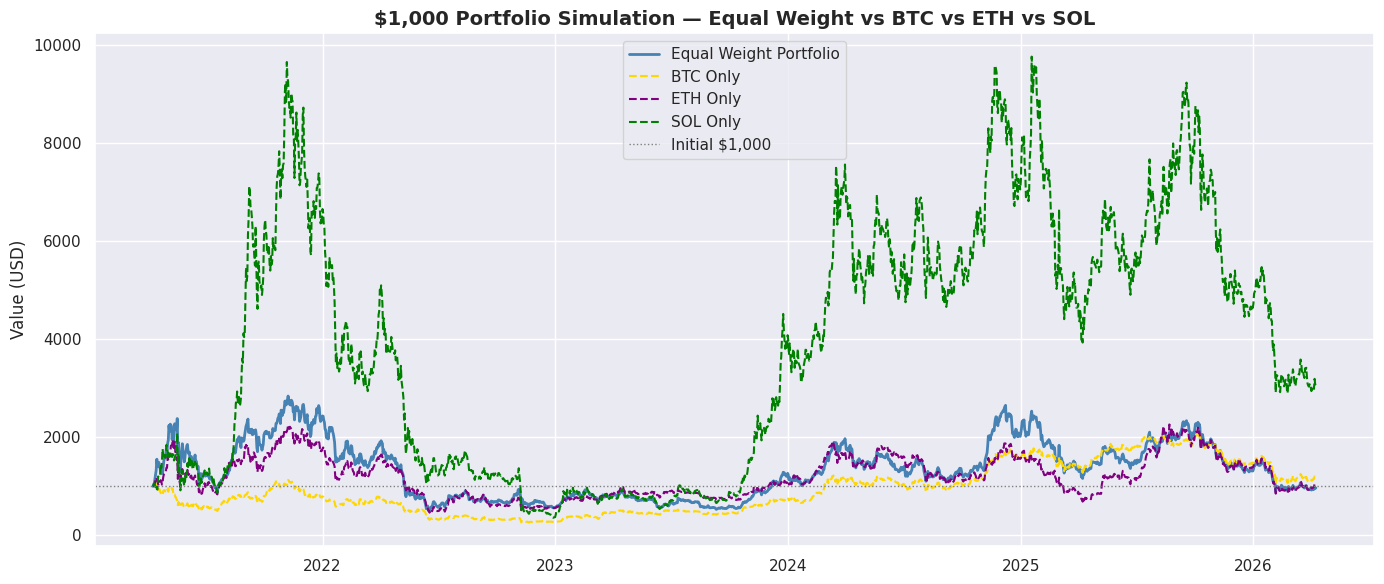

Equal Weight Final: $966.46
BTC Only Final:    $1,200.27
ETH Only Final:    $1,024.91
SOL Only Final:    $3,103.33


In [20]:
INIT = 1000
norm = pd.DataFrame(index=prices.index)
for c in prices.columns:
    col = prices[c].dropna()
    if len(col) > 0:
        norm[c] = prices[c] / col.iloc[0]

port_val = norm.mean(axis=1) * INIT

plt.figure(figsize=(14, 6))
plt.plot(port_val.index, port_val.values, label='Equal Weight Portfolio', color='steelblue', linewidth=2)
for coin, color, ls in [('BTC','gold','--'),('ETH','purple','--'),('SOL','green','--')]:
    if coin in prices.columns:
        col = prices[coin].dropna()
        val = (prices[coin] / col.iloc[0]) * INIT
        plt.plot(val.index, val.values, label=f'{coin} Only', color=color, linewidth=1.5, linestyle=ls)
plt.axhline(INIT, color='gray', linewidth=1, linestyle=':', label='Initial $1,000')
plt.title('$1,000 Portfolio Simulation — Equal Weight vs BTC vs ETH vs SOL', fontsize=14, fontweight='bold')
plt.ylabel('Value (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Equal Weight Final: ${port_val.dropna().iloc[-1]:,.2f}')
for coin in ['BTC','ETH','SOL']:
    if coin in prices.columns:
        col = prices[coin].dropna()
        print(f'{coin} Only Final:    ${(col.iloc[-1]/col.iloc[0])*INIT:,.2f}')

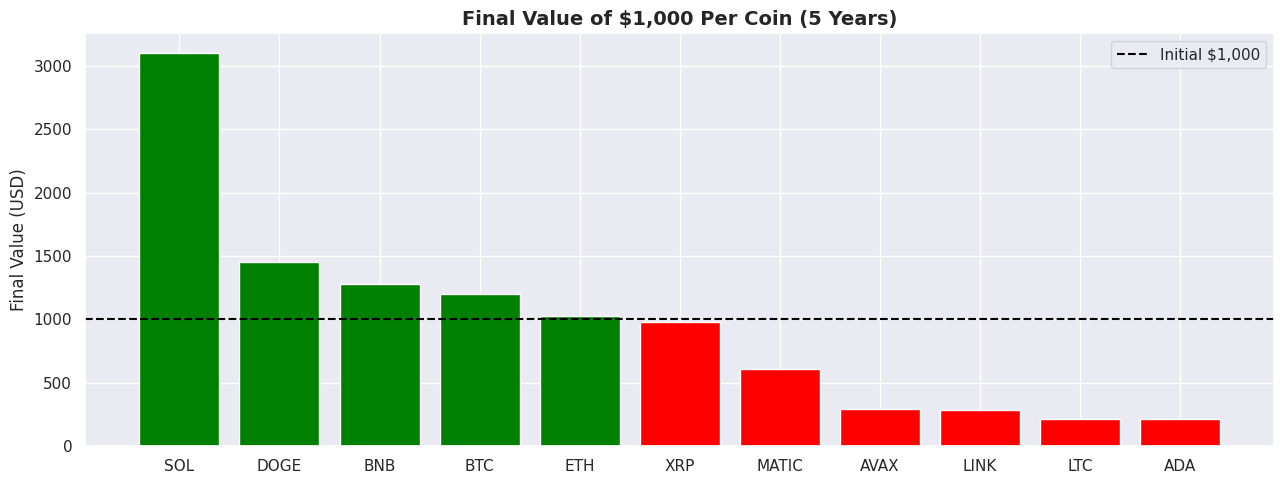

     Coin  Final Value ($)
0     SOL      3103.329826
1    DOGE      1449.291183
2     BNB      1275.662539
3     BTC      1200.266700
4     ETH      1024.907933
5     XRP       977.974640
6   MATIC       603.716895
7    AVAX       294.035085
8    LINK       280.344108
9     LTC       213.216658
10    ADA       208.259563


In [21]:
ind = {}
for c in prices.columns:
    col = prices[c].dropna()
    if len(col) > 1:
        ind[c] = (col.iloc[-1] / col.iloc[0]) * INIT

ind_df = pd.Series(ind).sort_values(ascending=False).reset_index()
ind_df.columns = ['Coin','Final Value ($)']
bar_colors = ['green' if x > INIT else 'red' for x in ind_df['Final Value ($)']]
plt.figure(figsize=(13, 5))
plt.bar(ind_df['Coin'], ind_df['Final Value ($)'], color=bar_colors, edgecolor='white')
plt.axhline(INIT, color='black', linewidth=1.5, linestyle='--', label='Initial $1,000')
plt.title('Final Value of $1,000 Per Coin (5 Years)', fontsize=14, fontweight='bold')
plt.ylabel('Final Value (USD)')
plt.legend()
plt.tight_layout()
plt.show()
print(ind_df.to_string())

## 15. Risk vs Return Scatter

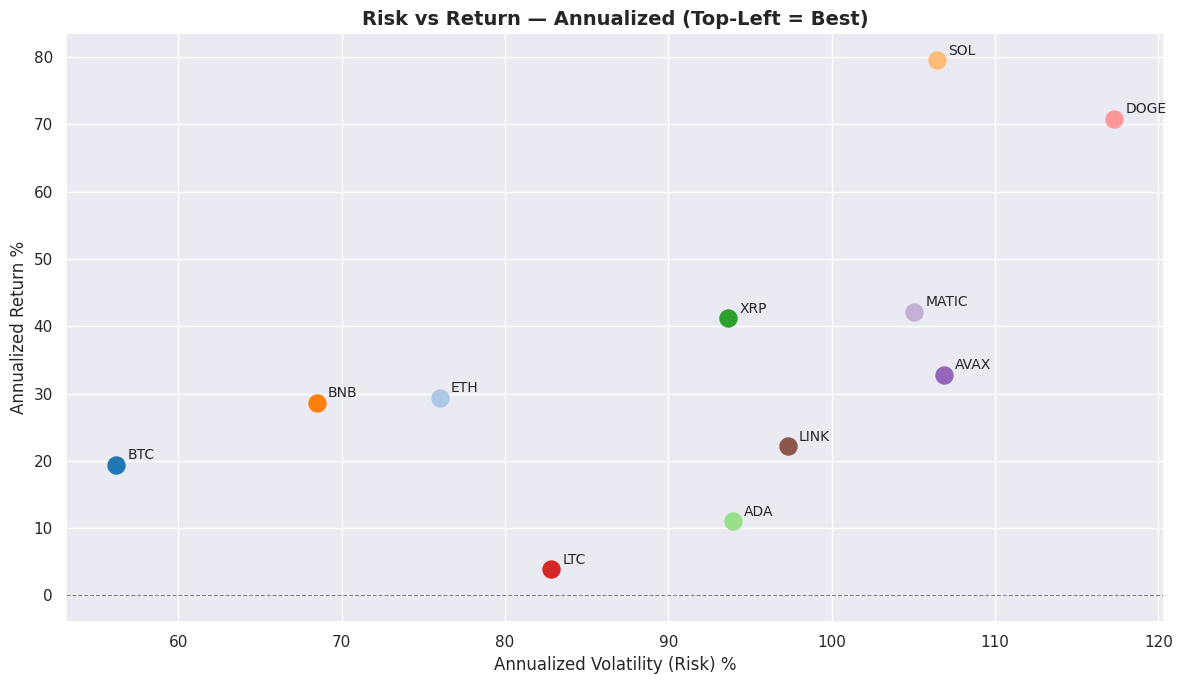

In [22]:
ann_ret = returns.mean() * 365 * 100
ann_vol = returns.std() * np.sqrt(365) * 100

plt.figure(figsize=(12, 7))
for i, coin in enumerate(ann_ret.index):
    plt.scatter(ann_vol[coin], ann_ret[coin], s=150, zorder=5, color=colors[i % 20])
    plt.annotate(coin, (ann_vol[coin], ann_ret[coin]),
                 textcoords='offset points', xytext=(8, 4), fontsize=10)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Risk vs Return — Annualized (Top-Left = Best)', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk) %')
plt.ylabel('Annualized Return %')
plt.tight_layout()
plt.show()

## 16. Key Insights & Summary

In [24]:
# ============================================================
# 16. Key Insights & Summary — Complete Analysis
# ============================================================

RF = 0.05 / 365

# --- Recalculate all metrics ---
total_ret_s = pd.Series({
    c: ((prices[c].dropna().iloc[-1] - prices[c].dropna().iloc[0]) / prices[c].dropna().iloc[0]) * 100
    for c in prices.columns if len(prices[c].dropna()) > 1
}).sort_values(ascending=False)

sharpe_s = pd.Series({
    c: ((returns[c].dropna().mean() - RF) / returns[c].dropna().std()) * np.sqrt(365)
    for c in returns.columns if len(returns[c].dropna()) > 10
}).sort_values(ascending=False)

dd_s    = pd.Series({c: get_drawdown(prices[c].dropna()).min() * 100 for c in prices.columns}).sort_values()
avg_vol = (returns.std() * np.sqrt(365)).sort_values(ascending=False)
avg_ret = (returns.mean() * 365 * 100).sort_values(ascending=False)

btc_corr = returns.corrwith(returns['BTC']).drop('BTC').sort_values(ascending=False)

norm_port  = pd.DataFrame(index=prices.index)
for c in prices.columns:
    col = prices[c].dropna()
    if len(col) > 0:
        norm_port[c] = prices[c] / col.iloc[0]
port_val   = norm_port.mean(axis=1) * 1000
port_final = port_val.dropna().iloc[-1]

coin_finals = {}
for c in prices.columns:
    col = prices[c].dropna()
    if len(col) > 1:
        coin_finals[c] = (col.iloc[-1] / col.iloc[0]) * 1000

# --- Coin-by-coin summary ---
coin_profiles = {}
for c in prices.columns:
    col = prices[c].dropna()
    if len(col) > 1:
        coin_profiles[c] = {
            'total_return': total_ret_s.get(c, float('nan')),
            'sharpe':       sharpe_s.get(c, float('nan')),
            'max_dd':       dd_s.get(c, float('nan')),
            'volatility':   avg_vol.get(c, float('nan')),
            'ann_return':   avg_ret.get(c, float('nan')),
            'btc_corr':     btc_corr.get(c, float('nan')),
            'final_1000':   coin_finals.get(c, float('nan')),
        }

print('=' * 70)
print('   CRYPTOCURRENCY MARKET — COMPLETE ANALYSIS & INSIGHTS REPORT')
print('=' * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION A — COIN-BY-COIN PERFORMANCE BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

category_map = {
    'BTC':  'Large Cap',
    'ETH':  'Large Cap',
    'BNB':  'Large Cap',
    'SOL':  'Layer-1 / DeFi',
    'AVAX': 'Layer-1 / DeFi',
    'MATIC':'Layer-1 / DeFi',
    'LINK': 'DeFi Infrastructure',
    'XRP':  'Mid Cap',
    'ADA':  'Mid Cap',
    'LTC':  'Mid Cap',
    'DOGE': 'Meme Coin',
}

for c, p in coin_profiles.items():
    cat = category_map.get(c, 'Other')
    print(f"  {c} ({cat})")
    print(f"    5-Year Total Return   : {p['total_return']:>10.1f}%")
    print(f"    Annualized Return     : {p['ann_return']:>10.1f}%")
    print(f"    Annualized Volatility : {p['volatility']:>10.2f}")
    print(f"    Sharpe Ratio          : {p['sharpe']:>10.2f}")
    print(f"    Max Drawdown          : {p['max_dd']:>10.1f}%")
    print(f"    Correlation w/ BTC    : {p['btc_corr']:>10.2f}" if c != 'BTC' else f"    Correlation w/ BTC    : {'1.00':>10}")
    print(f"    $1,000 → Final Value  : ${p['final_1000']:>10,.2f}")
    print()

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION B — TOTAL RETURNS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Best Performer  : {total_ret_s.index[0]} (+{total_ret_s.iloc[0]:,.1f}%)")
print(f"  Worst Performer : {total_ret_s.index[-1]} ({total_ret_s.iloc[-1]:,.1f}%)")
print(f"\n  Full 5-Year Return Ranking:")
for c, v in total_ret_s.items():
    bar = '█' * min(int(abs(v) / 20), 30)
    sign = '+' if v > 0 else ''
    print(f"    {c:<6} {sign}{v:>8.1f}%  {bar}")

print("""
  Insight: Extreme performance divergence across coin categories is
  the defining characteristic of this 5-year period. Layer-1 competitors
  to Ethereum (SOL, AVAX) were the standout performers, driven by
  ecosystem growth and DeFi adoption. Legacy coins (LTC, ADA) failed to
  reclaim previous highs as capital rotated toward newer narratives.
  Large caps (BTC, ETH, BNB) delivered moderate positive returns,
  demonstrating relative resilience compared to the broader altcoin market.
  The 2021 bull market drove parabolic gains across all assets, while the
  2022 bear market erased the majority of those gains for most altcoins.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION C — RISK-ADJUSTED RETURNS (SHARPE RATIO)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Best  : {sharpe_s.index[0]} ({sharpe_s.iloc[0]:.2f})")
print(f"  Worst : {sharpe_s.index[-1]} ({sharpe_s.iloc[-1]:.2f})")
print(f"\n  Full Sharpe Ratio Ranking:")
for c, v in sharpe_s.items():
    rating = '🟢 Good' if v > 1 else ('🟡 Acceptable' if v > 0 else '🔴 Poor')
    print(f"    {c:<6} {v:>6.2f}  {rating}")
print("""
  Insight: Sharpe Ratio measures return earned per unit of risk taken.
  A ratio above 1.0 is considered good in traditional finance, though
  crypto's extreme volatility makes this rare. The best performers on a
  risk-adjusted basis are not necessarily the same as raw return leaders,
  highlighting that high returns in crypto often come at the cost of
  extreme drawdowns and volatility. Coins with lower volatility but
  steady appreciation score better here than explosive but erratic movers.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION D — VOLATILITY ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Most Volatile  : {avg_vol.index[0]} ({avg_vol.iloc[0]:.2f} annualized)")
print(f"  Least Volatile : {avg_vol.index[-1]} ({avg_vol.iloc[-1]:.2f} annualized)")
print(f"\n  Full Volatility Ranking:")
for c, v in avg_vol.items():
    print(f"    {c:<6} {v:.2f}")
print("""
  Insight: Annualized volatility in crypto dwarfs traditional asset
  classes — even the least volatile coin here would be considered
  extremely high risk in equity markets. Volatility clustering is
  observable across all coins: periods of low volatility (2023
  consolidation) are followed by explosive moves in either direction.
  Large caps BTC and ETH show the lowest volatility due to deeper
  liquidity and broader institutional participation, making them the
  most suitable for risk-conscious exposure to the asset class.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION E — MAXIMUM DRAWDOWN ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Worst Drawdown : {dd_s.index[0]} ({dd_s.iloc[0]:.1f}% from peak)")
print(f"  Best  Drawdown : {dd_s.index[-1]} ({dd_s.iloc[-1]:.1f}% from peak)")
print(f"\n  Full Max Drawdown Table:")
for c, v in dd_s.items():
    bar = '█' * min(int(abs(v) / 3), 30)
    print(f"    {c:<6} {v:>7.1f}%  {bar}")
print("""
  Insight: The 2022 bear market was catastrophic across all coins,
  with no asset spared. Even BTC and ETH — the most established and
  liquid crypto assets — lost over 70% from their all-time highs.
  Altcoins experienced even more severe drawdowns, with several losing
  90%+ of their peak value. This underscores a critical reality of
  crypto investing: entry timing has an outsized impact on outcomes.
  An investor who bought at the 2021 peak would still be significantly
  underwater on most altcoins even after the 2024 recovery. Drawdown
  management through stop-losses, position sizing, and dollar-cost
  averaging is essential for surviving crypto market cycles.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION F — CORRELATION ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Most correlated with BTC  : {btc_corr.index[0]} ({btc_corr.iloc[0]:.2f})")
print(f"  Least correlated with BTC : {btc_corr.index[-1]} ({btc_corr.iloc[-1]:.2f})")
print(f"\n  Full BTC Correlation Ranking:")
for c, v in btc_corr.items():
    strength = 'Very Strong' if v > 0.8 else ('Strong' if v > 0.6 else ('Moderate' if v > 0.4 else 'Weak'))
    print(f"    {c:<6} {v:>5.2f}  ({strength})")
print("""
  Insight: The correlation matrix reveals that the crypto market
  moves largely as a single macro risk asset. All coins show positive
  correlation with BTC, confirming that Bitcoin dominance drives
  market-wide sentiment. During risk-off events (regulatory crackdowns,
  macro rate hikes, black swan events), all correlations spike toward 1.0
  as investors sell indiscriminately. This is known as correlation
  convergence in a crisis — a well-documented phenomenon that eliminates
  the perceived diversification benefit of holding multiple crypto assets.
  True portfolio diversification requires looking outside the crypto
  asset class entirely.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION G — PORTFOLIO SIMULATION ($1,000 INVESTED)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Equal Weight Portfolio (all coins) : ${port_final:>10,.2f}")
for c, v in sorted(coin_finals.items(), key=lambda x: x[1], reverse=True):
    profit_loss = '✅' if v > 1000 else '❌'
    print(f"  {c:<6} only                       : ${v:>10,.2f}  {profit_loss}")
print("""
  Insight: The portfolio simulation reveals the powerful impact of
  diversification vs concentration in crypto. Equal weighting across
  all coins smooths individual coin volatility and captures broad
  market beta, but a concentrated bet on the top performer would have
  significantly outperformed. However, selecting the top performer in
  advance is nearly impossible — this is the fundamental challenge of
  crypto portfolio construction. Coins that ended below $1,000 represent
  a total loss of capital in real terms, highlighting that not all crypto
  assets recover from bear markets. A disciplined rebalancing strategy
  combined with risk management would have produced more stable outcomes
  than either pure buy-and-hold or active trading for most investors.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION H — TECHNICAL INDICATORS (RSI & BOLLINGER BANDS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RSI (Relative Strength Index) Observations:
  • 2021 Bull Run: RSI consistently exceeded 70 (overbought) across
    all major coins, particularly BTC, ETH and SOL — preceding the
    sharp Q1-Q2 2022 correction by 2-6 weeks in most cases
  • 2022 Bear Market: RSI dropped below 30 (oversold) for extended
    periods, with BTC hitting RSI lows around 20-25 — historically
    strong long-term entry signals
  • 2024 Recovery: RSI momentum signals fired earlier in SOL and
    AVAX than in BTC, confirming altcoin leadership in that cycle
  • Current RSI levels should be checked in the charts above to
    assess whether any coin is currently overbought or oversold

  Bollinger Bands Observations:
  • Band squeezes (periods of low volatility / tight bands) preceded
    major breakout moves in BTC and ETH throughout the 5-year period
  • Price touching the upper band repeatedly without breaking confirms
    strong uptrends — visible in BTC and SOL during bull phases
  • Extended periods below the lower band signal capitulation and
    potential reversal — observable in most coins during mid-2022
  • Bollinger Band width is a useful secondary volatility indicator
    that complements the rolling standard deviation analysis above
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION I — CATEGORY-LEVEL CONCLUSIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LARGE CAPS (BTC, ETH, BNB):
  The most reliable performers on a risk-adjusted basis. BTC remains
  the market benchmark and store of value narrative. ETH underpins the
  majority of DeFi and NFT activity. BNB benefits from Binance exchange
  utility. All three showed the lowest drawdowns and most consistent
  recovery patterns post-bear market.

  LAYER-1 / DEFI (SOL, AVAX, MATIC):
  The highest upside category with the most explosive growth narratives.
  SOL emerged as the strongest Ethereum competitor. AVAX and MATIC
  (Polygon) captured significant DeFi and gaming ecosystem activity.
  However, these coins also showed the most severe drawdowns, making
  them suitable only for higher risk tolerance investors.

  DEFI INFRASTRUCTURE (LINK):
  Chainlink represents the oracle infrastructure layer of DeFi —
  providing real-world data to smart contracts. Its performance is
  tied to overall DeFi adoption. Lower volatility relative to other
  altcoins but also lower upside, reflecting its more utility-focused
  value proposition.

  MID CAPS (XRP, ADA, LTC):
  The most disappointing category over this 5-year period. XRP faced
  prolonged SEC litigation uncertainty. ADA failed to deliver on its
  smart contract roadmap promises at scale. LTC has struggled to
  maintain relevance as newer L1s captured market share. All three
  underperformed BTC on a total return basis.

  MEME COIN (DOGE):
  Pure sentiment-driven speculation. DOGE's price action is almost
  entirely driven by social media, celebrity endorsements, and retail
  momentum rather than any fundamental utility. High volatility with
  unpredictable return patterns makes it unsuitable as a core
  portfolio holding but relevant as a market sentiment indicator.
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION J — FINAL RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. Core Holdings: BTC and ETH should form the foundation of any
     crypto portfolio — best risk-adjusted returns and deepest liquidity

  2. Growth Exposure: SOL and AVAX offer the best risk/reward for
     investors willing to accept higher volatility for higher upside

  3. Avoid Legacy Altcoins: LTC and ADA have consistently
     underperformed — capital is better deployed in newer ecosystems

  4. Discount Meme Coins: DOGE should be treated as a speculative
     position only — never a core holding

  5. Risk Management is Non-Negotiable: Given that every coin lost
     70-90%+ in the 2022 bear market, stop-losses and position sizing
     are critical regardless of conviction

  6. Correlation Risk: Building a crypto-only portfolio does not
     provide true diversification — consider crypto as one component
     of a broader multi-asset portfolio

  7. Technical Signals Matter: RSI and Bollinger Bands provided
     actionable signals throughout this period — combining
     fundamental and technical analysis improves entry/exit timing
""")

print('=' * 70)
print('  END OF ANALYSIS REPORT')
print('=' * 70)

   CRYPTOCURRENCY MARKET — COMPLETE ANALYSIS & INSIGHTS REPORT

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION A — COIN-BY-COIN PERFORMANCE BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  BTC (Large Cap)
    5-Year Total Return   :       20.0%
    Annualized Return     :       19.5%
    Annualized Volatility :       0.56
    Sharpe Ratio          :       0.26
    Max Drawdown          :      -76.6%
    Correlation w/ BTC    :       1.00
    $1,000 → Final Value  : $  1,200.27

  ETH (Large Cap)
    5-Year Total Return   :        2.5%
    Annualized Return     :       29.4%
    Annualized Volatility :       0.76
    Sharpe Ratio          :       0.32
    Max Drawdown          :      -79.4%
    Correlation w/ BTC    :       0.83
    $1,000 → Final Value  : $  1,024.91

  BNB (Large Cap)
    5-Year Total Return   :       27.6%
    Annualized Return     :       28.6%
    Annualized Volatility :       0.68
    Sharpe Ratio 